# Voice of the Customer: Sarcasm-Aware Sentiment Analysis of Swiggy App Reviews

**Text Analytics · End-Term Project**
Prin. L. N. Welingkar Institute of Management Development & Research
---

## Marketing problem

Swiggy competes with Zomato (food delivery) and Zepto / Blinkit (quick commerce). Switching costs are close to zero, so every bad experience can cost a customer. The Play Store rating is also the first thing a new user sees. Management needs to know:

1. How do customers feel about Swiggy right now?
2. **What drives** that feeling: delivery time, fees, refunds, the app?
3. How much negative feeling is **hidden behind sarcasm** (*"Great job Swiggy, food came cold after 2 hours!"*), which basic sentiment tools read as praise?
4. What should the marketing and customer-experience teams **do** about it?

## Methodology

| Step in the brief | What this notebook does | Section |
|---|---|---|
| 1. Choose a relevant dataset (web-scraped) | Scrapes 3,000 newest Swiggy reviews + star ratings from Google Play | 1 |
| 2. Clean and normalise | Duplicates, short and non-English reviews removed; slang, contractions, stopwords, lemmatisation | 2 |
| 3. Feature extraction using TF-IDF | TF-IDF terms, distinctive terms, Logistic Regression, NMF topics | 6 |
| 4. Tri-gram + sentiment analysis with sarcasm detection | VADER vs TextBlob vs RoBERTa, validated on star ratings; hybrid sarcasm detector; tri-grams | 4, 5, 7 |
| 5. Unigram analysis + word cloud | Top unigrams; word clouds for all / negative / positive reviews | 8 |
| 6. Interpret and suggest strategies | Aspect-based sentiment, pain-point ranking, data-driven insights and strategies with KPIs | 9, 10, 11 |


## Setup: libraries, configuration and chart style

**Logic:**
- The notebook installs any missing library itself, so it runs top to bottom on a fresh Colab with no manual setup.
- All settings (company, number of reviews, thresholds, model names) are in one configuration block, so the analysis can be repeated for another app (e.g. Zomato) by changing only `APP_ID`.
- **Colour logic for charts:** sentiment is a polarity (bad ↔ good), so it uses a diverging pair: **red = negative, grey = neutral, blue = positive**. Blue/red stays readable for colour-blind readers, unlike red/green.

In [7]:
import importlib.util
import os
import re
import subprocess
import sys
import textwrap
import time
import warnings
from collections import Counter
from functools import lru_cache

warnings.filterwarnings("ignore")
try:                                    # Windows consoles: allow printing the star symbol
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

REQUIRED_PACKAGES = {                      # import name : pip name
    "google_play_scraper": "google-play-scraper",
    "nltk": "nltk",
    "vaderSentiment": "vaderSentiment",
    "textblob": "textblob",
    "wordcloud": "wordcloud",
    "contractions": "contractions",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}


def ensure_packages(packages):
    """Install any package that is not already importable."""
    missing = [pip for mod, pip in packages.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


ensure_packages(REQUIRED_PACKAGES)

# Charts: shown inline in a notebook, saved as PNG files when run as a script.
IN_NOTEBOOK = "ipykernel" in sys.modules
if not IN_NOTEBOOK:
    os.environ["MPLBACKEND"] = "Agg"

import matplotlib                                       # noqa: E402
import matplotlib.pyplot as plt                         # noqa: E402
import numpy as np                                      # noqa: E402
import pandas as pd                                     # noqa: E402
import nltk                                             # noqa: E402

for resource in ["stopwords", "wordnet", "omw-1.4",
                 "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

from nltk.corpus import stopwords, wordnet                               # noqa: E402
from nltk.stem import WordNetLemmatizer                                  # noqa: E402
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer    # noqa: E402
from textblob import TextBlob                                            # noqa: E402
from wordcloud import WordCloud                                          # noqa: E402
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer  # noqa: E402
from sklearn.linear_model import LogisticRegression                      # noqa: E402
from sklearn.pipeline import make_pipeline                               # noqa: E402
from sklearn.model_selection import StratifiedKFold, cross_validate      # noqa: E402
from sklearn.decomposition import NMF                                    # noqa: E402
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report  # noqa: E402

try:
    import contractions
    HAS_CONTRACTIONS = True
except Exception:
    HAS_CONTRACTIONS = False

Installing missing packages: google-play-scraper, vaderSentiment, contractions


In [8]:
# ------------------------------- configuration -------------------------------
COMPANY = "Swiggy"
APP_ID = "in.swiggy.android"   # Play Store id of the Swiggy app
LANG, COUNTRY = "en", "in"     # English reviews from Indian users
N_REVIEWS = 3000               # newest reviews to scrape
MIN_WORDS = 3                  # shorter reviews ("good", "nice app") carry no "why"
ENGLISH_THRESHOLD = 0.60       # share of recognised English words needed to keep a review
USE_TRANSFORMERS = True        # RoBERTa sentiment + irony models (falls back if unavailable)
SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
IRONY_MODEL = "cardiffnlp/twitter-roberta-base-irony"
REFRESH_DATA = False           # True = scrape again even if the CSV already exists
RANDOM_STATE = 42

OUTPUT_DIR = "swiggy_project_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RAW_CSV = os.path.join(OUTPUT_DIR, "01_swiggy_reviews_raw.csv")
np.random.seed(RANDOM_STATE)

In [9]:
# ------------------------------- plotting style ------------------------------
# Logic: sentiment is a polarity (bad <-> good), so it uses a diverging pair:
# red = negative, grey = neutral, blue = positive. Blue/red stays readable for
# colour-blind readers, unlike red/green.
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
SENT_ORDER = ["Negative", "Neutral", "Positive"]
SENT_COLORS = {"Negative": "#e34948", "Neutral": "#a8a7a0", "Positive": "#2a78d6"}
STAR_COLORS = {1: "#e34948", 2: "#f0a09f", 3: "#a8a7a0", 4: "#86b6ef", 5: "#2a78d6"}
ACCENT = "#4a3aa7"   # single-series charts that are not about polarity

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": INK2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "font.family": "sans-serif", "legend.frameon": False, "legend.fontsize": 9,
})

_fig_no = [0]


def save_show(fig, name):
    """Save every chart to the outputs folder (and show it in a notebook)."""
    _fig_no[0] += 1
    path = os.path.join(OUTPUT_DIR, f"fig{_fig_no[0]:02d}_{name}.png")
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  [chart saved] {path}")
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)


def hbar(ax, labels, values, color, title, xlabel):
    """Ranked horizontal bar chart (largest at the top)."""
    y = np.arange(len(labels))[::-1]
    ax.barh(y, values, color=color, height=0.72)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(title, loc="left")
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)


def section(title):
    print("\n" + "=" * 79 + f"\n{title}\n" + "=" * 79)


def short(text, n=160):
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text if len(text) <= n else text[: n - 3] + "..."

##  Data collection: web scraping Google Play Store reviews

**What:** scrape the 3,000 newest English reviews of the Swiggy app from the Indian Play Store using `google-play-scraper`.

**Why this source and this tool:**
- Amazon blocked the scraper we used in class (HTTP 503). E-commerce sites block automated traffic.
- Play Store reviews load via JavaScript, so `requests` + `BeautifulSoup` only sees an empty page. `google-play-scraper` calls the same endpoint the browser uses and returns clean records.
- Every review comes with the customer's **own star rating**. That is a free, independent label: we use it to test which sentiment model is most accurate, and it is the key signal for sarcasm (kind words + 1 star).

**Pagination** works like the "Next" button loop from class: each call returns about 200 reviews plus a *continuation token* that points at the next page. We loop until we have 3,000, pausing 1 second between requests to be polite.

**Reproducibility and privacy:** the raw data is saved to CSV and reused on re-runs (set `REFRESH_DATA = True` to scrape fresh reviews). User names and profile pictures are dropped because they are personal data we do not need.

##DATA COLLECTION (web scraping)

In [10]:
def scrape_play_store_reviews(app_id, n_reviews, lang, country, batch_size=200):
    from google_play_scraper import Sort, reviews
    collected, token = [], None
    while len(collected) < n_reviews:
        try:
            batch, token = reviews(app_id, lang=lang, country=country, sort=Sort.NEWEST,
                                   count=min(batch_size, n_reviews - len(collected)),
                                   continuation_token=token)
        except Exception as exc:
            print("  Scraping stopped:", exc)
            break
        if not batch:
            break
        collected.extend(batch)
        print(f"  page {len(collected) // batch_size + (len(collected) % batch_size > 0):>2}: "
              f"{len(collected):,} reviews collected")
        if token is None or getattr(token, "token", None) is None:
            break
        time.sleep(1)   # polite delay between requests (same as time.sleep(1) in class)
    return pd.DataFrame(collected)


def scrape_app_details(app_id, lang, country):
    try:
        from google_play_scraper import app
        info = app(app_id, lang=lang, country=country)
        return {k: info.get(k) for k in ["title", "score", "ratings", "reviews", "installs", "genre"]}
    except Exception:
        return {}

In [11]:
APP_INFO = scrape_app_details(APP_ID, LANG, COUNTRY)
if APP_INFO:
    print(f"App: {APP_INFO.get('title')} | Store rating: {APP_INFO.get('score')} | "
          f"Ratings: {APP_INFO.get('ratings')} | Installs: {APP_INFO.get('installs')}")

if os.path.exists(RAW_CSV) and not REFRESH_DATA:
    print(f"Loading previously scraped reviews from {RAW_CSV} "
          f"(set REFRESH_DATA = True to scrape again)")
    raw = pd.read_csv(RAW_CSV)
else:
    print(f"Scraping the {N_REVIEWS:,} newest {LANG.upper()} reviews of {APP_ID} "
          f"(country = {COUNTRY.upper()})...")
    raw = scrape_play_store_reviews(APP_ID, N_REVIEWS, LANG, COUNTRY)
    if raw.empty:
        raise RuntimeError("No reviews could be scraped. Check the internet connection and run again.")
    # Privacy: user names and profile pictures are personal data we do not need.
    raw = raw.drop(columns=[c for c in ["userName", "userImage"] if c in raw.columns])
    raw.to_csv(RAW_CSV, index=False)
    print(f"Saved raw data -> {RAW_CSV}")

print(f"Raw dataset: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print("Columns:", list(raw.columns))

App: Swiggy: Food Instamart Dineout | Store rating: 4.4963956 | Ratings: 13565024 | Installs: 100,000,000+
Scraping the 3,000 newest EN reviews of in.swiggy.android (country = IN)...
  page  1: 200 reviews collected
  page  2: 400 reviews collected
  page  3: 600 reviews collected
  page  4: 800 reviews collected
  page  5: 1,000 reviews collected
  page  6: 1,200 reviews collected
  page  7: 1,400 reviews collected
  page  8: 1,600 reviews collected
  page  9: 1,800 reviews collected
  page 10: 2,000 reviews collected
  page 11: 2,200 reviews collected
  page 12: 2,400 reviews collected
  page 13: 2,600 reviews collected
  page 14: 2,800 reviews collected
  page 15: 3,000 reviews collected
Saved raw data -> swiggy_project_outputs/01_swiggy_reviews_raw.csv
Raw dataset: 3,000 rows x 9 columns
Columns: ['reviewId', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


## 2. Data cleaning and normalisation

**Key design decision: two versions of every review**, because the two kinds of analysis need opposite preprocessing.

| Version | Used for | Treatment | Why |
|---|---|---|---|
| `sentiment_text` | VADER, TextBlob, RoBERTa | Light: keeps capitals, "!!!", emojis, "not", "very" | These change how strong a feeling is: "NOT good!!!" is more negative than "not good" |
| `clean_text` | TF-IDF, n-grams, word clouds | Full: lowercase, contractions expanded, slang merged, no numbers / punctuation / stopwords, lemmatised | "delivered", "Delivery" and "deliver" should count as one idea |

**Cleaning steps and the reason for each:**
1. **Missing / empty reviews** removed.
2. **Duplicates** removed. A repeated review ID is a scraping overlap; identical long texts from different users are copy-paste spam that would inflate n-gram counts.
3. **Reviews under 3 words** removed. "Good" has a rating but no *reason*, and this project is about *why*. Their average rating is reported so the removal is transparent.
4. **Hindi / Hinglish** removed. The Play Store language filter follows the phone's setting, not the review's language. English models would score "bahut bekar app hai" as neutral, so a review is kept only if at least 60% of its words are recognised English words.
5. **Normalisation:** a slang dictionary ("pls" → "please", "delivery boy / guy / executive" → "delivery partner") so one idea is not split across many n-grams; contractions expanded ("don't" → "do not").
6. **Stopwords:** the standard English list **minus negations** ("not delivered" ≠ "delivered") **plus** the brand name and filler words, which would otherwise dominate every word cloud without saying anything.
7. **POS-aware lemmatisation** of nouns and verbs ("delivered" → "deliver", "charges" → "charge"). Adjectives are deliberately left alone: WordNet would turn "worst" into "bad" and erase the customer's intensity.
8. **Label from the stars:** 1–2★ = Negative, 3★ = Neutral, 4–5★ = Positive. This is the customer's own verdict and serves as ground truth for testing the models.

In [12]:
df = raw.rename(columns={"content": "review", "score": "rating", "thumbsUpCount": "helpful_votes",
                         "at": "review_date", "replyContent": "company_reply",
                         "repliedAt": "reply_date", "appVersion": "app_version"}).copy()
for col in ["helpful_votes", "company_reply", "reply_date", "app_version", "reviewId"]:
    if col not in df.columns:
        df[col] = np.nan
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
df["reply_date"] = pd.to_datetime(df["reply_date"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["helpful_votes"] = pd.to_numeric(df["helpful_votes"], errors="coerce").fillna(0).astype(int)

log = [("Raw reviews scraped", len(df))]

In [13]:
# 2.1 Missing and empty reviews
df = df.dropna(subset=["review", "rating"])
df["review"] = df["review"].astype(str).str.strip()
df = df[df["review"] != ""]
log.append(("After removing empty reviews / ratings", len(df)))

In [14]:
# 2.2 Duplicates. A repeated reviewId is a scraping overlap. Identical long
# texts from different users are usually copy-paste spam and would inflate
# n-gram counts.
df = df.drop_duplicates(subset=["reviewId"]) if df["reviewId"].notna().any() else df
df = df.drop_duplicates(subset=["review"])
log.append(("After removing duplicates", len(df)))

In [15]:
# 2.3 Very short reviews. "Good" or "Nice app" gives a rating but no reason.
# This project is about WHY customers feel the way they do, so these are
# dropped. We report their average rating so the removal is transparent.
df["word_count"] = df["review"].str.split().str.len()
too_short = df[df["word_count"] < MIN_WORDS]
df = df[df["word_count"] >= MIN_WORDS]
log.append((f"After removing reviews with < {MIN_WORDS} words", len(df)))
print(f"Short reviews removed: {len(too_short):,} (their average rating = "
      f"{too_short['rating'].mean():.2f} stars, mostly one-word praise such as 'good'/'nice')")

Short reviews removed: 498 (their average rating = 4.16 stars, mostly one-word praise such as 'good'/'nice')


In [16]:
# 2.4 Language filter. The Play Store 'lang=en' filter follows the user's phone
# language, not the review language, so Hindi and Hinglish reviews
# ("bahut bekar app hai") get through. VADER, TextBlob and RoBERTa are English
# models and would score them as neutral. We keep a review only if at least
# 60% of its words are recognised English words (WordNet + stopwords + a small
# domain list).
EN_STOP = set(stopwords.words("english"))
DOMAIN_VOCAB = {"swiggy", "instamart", "zomato", "zepto", "blinkit", "app", "apps", "upi", "otp", "gst",
                "ok", "okay", "pls", "plz", "u", "ur", "thanku", "refund", "refunded", "refunds",
                "coupon", "coupons", "cashback", "paytm", "gpay", "phonepe", "wtf", "lol", "bcoz", "coz"}


@lru_cache(maxsize=None)
def is_english_word(word):
    return word in EN_STOP or word in DOMAIN_VOCAB or wordnet.morphy(word) is not None


def english_ratio(text):
    words = re.findall(r"[a-z]+", text.lower())
    return np.mean([is_english_word(w) for w in words]) if words else 0.0


df["english_ratio"] = df["review"].apply(english_ratio)
non_english = df[df["english_ratio"] < ENGLISH_THRESHOLD]
df = df[df["english_ratio"] >= ENGLISH_THRESHOLD]
log.append(("After removing Hindi / Hinglish reviews", len(df)))
if len(non_english):
    print("Examples of removed non-English reviews:")
    for t in non_english["review"].head(3):
        print("   -", short(t, 90))

Examples of removed non-English reviews:
   - mane ek rs section se chize mangai usne likha vo aayge but mujhe item received nhi hue ...
   - sab faltu app h koi bhi oder na kre is app se kuch bhi 20 minutes dikha kar 1:30 mints ...
   - tum log bohot gatiya ho tumhara aap kissi insan ko use kabhi Krna hi nhi chiye


In [17]:
# 2.5 Normalisation helpers
URL_RE = re.compile(r"https?://\S+|www\.\S+")
ELONGATED_RE = re.compile(r"([a-zA-Z])\1{2,}")      # "sooooo gooood" -> "soo good"

# Domain slang dictionary. Customers write the same idea many ways. Merging the
# variants stops one idea being split across several n-grams.
SLANG_MAP = {
    r"\bpl[sz]\b": "please", r"\bu\b": "you", r"\bur\b": "your", r"\b(?:b?coz|bcz|cuz)\b": "because",
    r"\bthanku\b": "thank you", r"\btym\b": "time", r"\bmins?\b": "minutes", r"\bhrs?\b": "hours",
    r"\bamt\b": "amount", r"\bqty\b": "quantity", r"\bmsg\b": "message", r"\bcust(?:omer)? care\b": "customer care",
    r"\bcc\b": "customer care", r"\binsta ?mart\b": "instamart", r"\b(?:rs|inr)\b": "rupees",
    r"\bdelivery (?:boy|guy|man|men|person|executive|agent|associate|rider|valet)s?\b": "delivery partner",
    r"\bdelivery partners\b": "delivery partner", r"\bdel(?:ivery)? boy\b": "delivery partner",
    r"\bapp'?s\b": "app", r"\bwont\b": "will not", r"\bcant\b": "cannot", r"\bdont\b": "do not",
    r"\bdidnt\b": "did not", r"\bdoesnt\b": "does not", r"\bisnt\b": "is not", r"\bwasnt\b": "was not",
}

# Stopwords: the standard English list MINUS negations. "not delivered" and
# "delivered" mean opposite things, so negations must survive for n-grams.
# We ADD the brand name and filler words, which appear everywhere and would
# otherwise dominate every word cloud without saying anything.
NEGATIONS = {"no", "not", "nor", "never"}
CUSTOM_STOP = {"swiggy", "app", "application", "please", "also", "even", "get", "got", "would", "could",
               "really", "use", "using", "used", "like", "one", "u", "ur", "im", "ive", "yes", "ok",
               "okay", "guy", "thing", "lot", "hai", "ki", "ka", "ke"}
STOP_WORDS = (EN_STOP - NEGATIONS) | CUSTOM_STOP
LEMMATIZER = WordNetLemmatizer()


def light_clean(text):
    """Minimal cleaning for sentiment models: keeps case, punctuation and emojis."""
    text = URL_RE.sub(" ", str(text))
    text = ELONGATED_RE.sub(r"\1\1", text)
    return re.sub(r"\s+", " ", text).strip()


def normalise(text):
    """Lowercase, expand contractions, map slang, keep letters only."""
    text = light_clean(text).lower()
    text = text.replace("’", "'").replace("‘", "'")
    for pattern, repl in SLANG_MAP.items():      # slang first, so "ur" -> "your" (not "you are")
        text = re.sub(pattern, repl, text)
    if HAS_CONTRACTIONS:
        text = contractions.fix(text)            # "don't" -> "do not", "im" -> "i am"
    text = re.sub(r"[^a-z\s]", " ", text)          # numbers, punctuation, emojis
    return re.sub(r"\s+", " ", text).strip()


def wordnet_pos(tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}.get(tag[:1], wordnet.NOUN)


def lemmatize_tokens(tokens):
    """POS-aware lemmatisation of nouns and verbs: 'delivered' -> 'deliver',
    'charges' -> 'charge'. Without a POS tag WordNet treats every word as a noun
    and misses verbs. Adjectives and adverbs are deliberately NOT lemmatised,
    because WordNet maps 'worst' -> 'bad' and 'best' -> 'good', which would
    erase the intensity of the customer's words."""
    try:
        tagged = nltk.pos_tag(tokens)       # tag the full sentence: context improves tags
    except Exception:
        tagged = [(w, "NN") for w in tokens]
    return [LEMMATIZER.lemmatize(w, wordnet_pos(t)) if t[:1] in ("N", "V") else w for w, t in tagged]


def full_clean(norm_text):
    tokens = lemmatize_tokens(norm_text.split())
    return " ".join(w for w in tokens if w not in STOP_WORDS and len(w) > 1)


df["sentiment_text"] = df["review"].apply(light_clean)
df["norm_text"] = df["review"].apply(normalise)     # used for aspect detection
df["clean_text"] = df["norm_text"].apply(full_clean)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
log.append(("Final analysable reviews", len(df)))

In [18]:
# 2.6 Label derived from the stars. The rating is the customer's own summary
# of how they feel, so we use it as ground truth to test the models:
# 1-2 stars = Negative, 3 = Neutral, 4-5 = Positive.
df["rating"] = df["rating"].astype(int)
df["star_sentiment"] = pd.cut(df["rating"], bins=[0, 2, 3, 5], labels=SENT_ORDER).astype(str)

print("\nCleaning funnel:")
for step, n in log:
    print(f"  {step:<48} {n:>6,}")
print("\nBefore vs after cleaning (3 examples):")
for _, r in df.sample(min(3, len(df)), random_state=RANDOM_STATE).iterrows():
    print(f"  ORIGINAL : {short(r['review'], 120)}")
    print(f"  CLEANED  : {short(r['clean_text'], 120)}\n")

df.to_csv(os.path.join(OUTPUT_DIR, "02_swiggy_reviews_clean.csv"), index=False)


Cleaning funnel:
  Raw reviews scraped                               3,000
  After removing empty reviews / ratings            3,000
  After removing duplicates                         1,762
  After removing reviews with < 3 words             1,264
  After removing Hindi / Hinglish reviews           1,146
  Final analysable reviews                          1,145

Before vs after cleaning (3 examples):
  ORIGINAL : the food is in very high rate
  CLEANED  : food high rate

  ORIGINAL : worst app use zomato instead
  CLEANED  : worst zomato instead

  ORIGINAL : always the delivery guy gets another order and delivers me order late whenever we complaint there is only one answer ...
  CLEANED  : always delivery partner another order delivers order late whenever complaint answer another parcel tat give take hour...



## 3. Exploratory data analysis

Before modelling we check the shape of the data:
- **Rating distribution:** how polarised are customers?
- **Review length by rating:** do unhappy customers write more? Long complaints are detailed diagnoses, which the aspect analysis in Section 9 can use.
- **Company reply rate:** how often does Swiggy publicly reply to complaints? Public replies are a cheap reputation lever, so this is a marketing metric in itself.

In [19]:
section("SECTION 3 - EXPLORATORY DATA ANALYSIS")

N = len(df)
date_min, date_max = df["review_date"].min(), df["review_date"].max()
print(f"Reviews analysed : {N:,}")
if pd.notna(date_min):
    print(f"Period covered   : {date_min:%d %b %Y} to {date_max:%d %b %Y}")
print(f"Average rating   : {df['rating'].mean():.2f} stars")
rating_share = df["rating"].value_counts(normalize=True).sort_index() * 100
print("Rating distribution (%):", {int(k): round(v, 1) for k, v in rating_share.items()})

# Do unhappy customers write more? A long complaint is a detailed diagnosis,
# which is useful for aspect analysis later.
length_by_star = df.groupby("rating")["word_count"].median()
print("Median review length (words) by star:", length_by_star.to_dict())

# Does Swiggy reply to reviews? Replying publicly to complaints is a cheap
# reputation lever, so we measure it.
df["has_reply"] = df["company_reply"].notna() & (df["company_reply"].astype(str).str.strip() != "")
reply_rate = df.groupby("star_sentiment")["has_reply"].mean().reindex(SENT_ORDER) * 100
print("Company reply rate by star sentiment (%):", reply_rate.round(1).to_dict())


SECTION 3 - EXPLORATORY DATA ANALYSIS
Reviews analysed : 1,145
Period covered   : 23 Sep 2026 to 30 Sep 2026
Average rating   : 2.45 stars
Rating distribution (%): {1: 57.9, 2: 3.7, 3: 4.1, 4: 4.5, 5: 29.8}
Median review length (words) by star: {1: 21.0, 2: 9.5, 3: 5.0, 4: 5.0, 5: 5.0}
Company reply rate by star sentiment (%): {'Negative': 99.4, 'Neutral': 100.0, 'Positive': 99.5}


  [chart saved] swiggy_project_outputs/fig01_eda_ratings_and_length.png


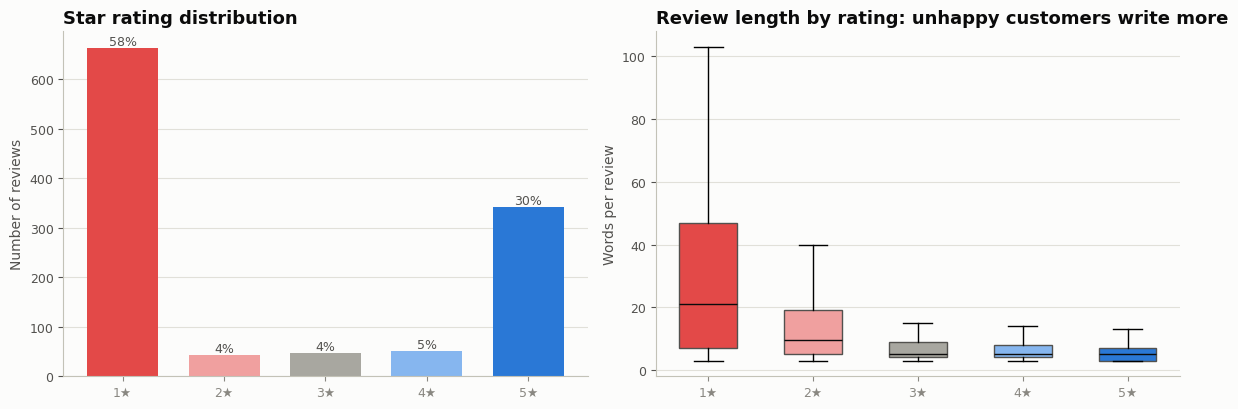

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
counts = df["rating"].value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
bars = axes[0].bar([f"{s}★" for s in counts.index], counts.values,
                   color=[STAR_COLORS[s] for s in counts.index], width=0.7)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f"{v / N:.0%}", ha="center", va="bottom",
                 fontsize=9, color=INK2)
axes[0].set_title("Star rating distribution", loc="left")
axes[0].set_ylabel("Number of reviews")
axes[0].grid(axis="x", visible=False)

data = [df.loc[df["rating"] == s, "word_count"].values for s in [1, 2, 3, 4, 5]]
bp = axes[1].boxplot(data, patch_artist=True, showfliers=False, widths=0.55)
for patch, s in zip(bp["boxes"], [1, 2, 3, 4, 5]):
    patch.set_facecolor(STAR_COLORS[s])
    patch.set_edgecolor(INK2)
for med in bp["medians"]:
    med.set_color(INK)
axes[1].set_xticklabels([f"{s}★" for s in [1, 2, 3, 4, 5]])
unhappy_len = df.loc[df["rating"] <= 2, "word_count"].median()
happy_len = df.loc[df["rating"] >= 4, "word_count"].median()
axes[1].set_title("Review length by rating" + (": unhappy customers write more" if unhappy_len > happy_len
                                               else ""), loc="left")
axes[1].set_ylabel("Words per review")
axes[1].grid(axis="x", visible=False)
save_show(fig, "eda_ratings_and_length")

## 4. Sentiment analysis: three best-in-class approaches

Instead of trusting one tool, we compare three model families and **score each against the customers' own star ratings**.

| Model | Type | Strength | Labelling rule |
|---|---|---|---|
| **VADER** | Rule + lexicon, built for social media | Understands emojis, CAPS, "!!!", negation, boosters ("very") | compound ≥ +0.05 Positive, ≤ −0.05 Negative (thresholds from the VADER paper) |
| **TextBlob** | Pattern lexicon | Also measures *subjectivity* (fact vs opinion) | polarity ≥ +0.05 / ≤ −0.05 |
| **RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) | Transformer trained on ~124M tweets | Reads the whole sentence in context: handles "not bad at all" and long mixed reviews | highest of negative / neutral / positive probability |

**Model selection logic:** macro-F1 (the average F1 over the three classes) against the star labels. Macro-F1 is used instead of plain accuracy so a model cannot score well by calling everything "Positive". The winning model's output becomes the **literal sentiment**, which Section 5 then corrects for sarcasm.

If the transformer cannot be loaded (no internet or no PyTorch), the notebook automatically continues with VADER and TextBlob.

In [21]:
import re
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Ensure df is correctly initialized with 'review' and 'rating' columns from 'raw'
# This block mimics the essential parts of cell 5005d8f3 if df is still in its raw state.
if 'review' not in df.columns or 'rating' not in df.columns:
    if 'raw' in locals() and isinstance(raw, pd.DataFrame):
        df = raw.rename(columns={
            "content": "review", "score": "rating", "thumbsUpCount": "helpful_votes",
            "at": "review_date", "replyContent": "company_reply",
            "repliedAt": "reply_date", "appVersion": "app_version"
        }).copy()
        for col in ["helpful_votes", "company_reply", "reply_date", "app_version", "reviewId"]:
            if col not in df.columns:
                df[col] = np.nan
        df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
        df["reply_date"] = pd.to_datetime(df["reply_date"], errors="coerce")
        df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
        df["helpful_votes"] = pd.to_numeric(df["helpful_votes"], errors="coerce").fillna(0).astype(int)
    else:
        raise RuntimeError("DataFrame 'raw' not found or 'df' not initialized. Please run data collection cells (Section 1).")

# Ensure light_clean function and its dependencies are defined if not already in scope.
# This block mimics essential parts of cell d006c254.
if 'light_clean' not in globals():
    URL_RE = re.compile(r"https?://\S+|www\.\S+")
    ELONGATED_RE = re.compile(r"([a-zA-Z])\1{2,}")

    def light_clean(text):
        """Minimal cleaning for sentiment models: keeps case, punctuation and emojis."""
        text = URL_RE.sub(" ", str(text))
        text = ELONGATED_RE.sub(r"\1\1", text)
        return re.sub(r"\s+", " ", text).strip()

# Create 'sentiment_text' column if it's missing
# This block mimics the column creation part of cell d006c254.
if 'sentiment_text' not in df.columns:
    df["sentiment_text"] = df["review"].apply(light_clean)

def polarity_label(score, pos=0.05, neg=-0.05):
    return "Positive" if score >= pos else ("Negative" if score <= neg else "Neutral")

vader = SentimentIntensityAnalyzer()
vader_scores = pd.DataFrame(df["sentiment_text"].apply(vader.polarity_scores).tolist(), index=df.index)
df["vader_compound"], df["vader_pos"], df["vader_neg"] = (vader_scores["compound"],
                                                         vader_scores["pos"], vader_scores["neg"])
df["vader_sentiment"] = df["vader_compound"].apply(polarity_label)

blobs = df["sentiment_text"].apply(lambda t: TextBlob(t).sentiment)
df["textblob_polarity"] = blobs.apply(lambda s: s.polarity)
df["textblob_subjectivity"] = blobs.apply(lambda s: s.subjectivity)
df["textblob_sentiment"] = df["textblob_polarity"].apply(polarity_label)
print("VADER and TextBlob scoring complete.")

VADER and TextBlob scoring complete.


In [22]:
def run_hf_classifier(model_name, texts, batch_size=32, max_len=128):
    """Run a Hugging Face sequence-classification model and return class
    probabilities. Texts are sorted by length before batching so each batch
    needs less padding, which makes the run about 2x faster on CPU."""
    import torch
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device).eval()
    order = np.argsort([len(t) for t in texts])
    probs = np.zeros((len(texts), model.config.num_labels), dtype=np.float32)
    n_batches = int(np.ceil(len(texts) / batch_size))
    t0 = time.time()
    with torch.no_grad():
        for b in range(n_batches):
            idx = order[b * batch_size:(b + 1) * batch_size]
            enc = tok([texts[i] for i in idx], padding=True, truncation=True,
                      max_length=max_len, return_tensors="pt").to(device)
            probs[idx] = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
            if (b + 1) % 20 == 0 or b + 1 == n_batches:
                print(f"    {model_name.split('/')[-1]}: batch {b + 1}/{n_batches} "
                      f"({time.time() - t0:.0f}s, device={device})")
    id2label = {int(k): str(v).lower() for k, v in model.config.id2label.items()}
    return probs, id2label


def label_index(id2label, keyword, default, exclude=None):
    for i, lab in id2label.items():
        if keyword in lab and (exclude is None or exclude not in lab):
            return i
    return default

In [23]:
HAS_ROBERTA = HAS_IRONY_MODEL = False
if USE_TRANSFORMERS:
    try:
        ensure_packages({"transformers": "transformers", "torch": "torch"})
        texts = df["sentiment_text"].tolist()
        print(f"Running RoBERTa sentiment model on {len(texts):,} reviews...")
        probs, id2label = run_hf_classifier(SENTIMENT_MODEL, texts)
        i_neg = label_index(id2label, "neg", 0)
        i_neu = label_index(id2label, "neu", 1)
        i_pos = label_index(id2label, "pos", 2)
        df["roberta_neg"], df["roberta_neu"], df["roberta_pos"] = probs[:, i_neg], probs[:, i_neu], probs[:, i_pos]
        df["roberta_sentiment"] = pd.Series(probs[:, [i_neg, i_neu, i_pos]].argmax(axis=1)).map(
            dict(enumerate(SENT_ORDER))).values
        df["roberta_score"] = df["roberta_pos"] - df["roberta_neg"]      # -1 .. +1
        HAS_ROBERTA = True
    except Exception as exc:
        print(f"  RoBERTa sentiment skipped ({type(exc).__name__}: {short(exc, 120)}). "
              "Continuing with VADER / TextBlob.")

Running RoBERTa sentiment model on 1,145 reviews...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

    twitter-roberta-base-sentiment-latest: batch 20/36 (54s, device=cpu)
    twitter-roberta-base-sentiment-latest: batch 36/36 (183s, device=cpu)


In [24]:
# ---- Model evaluation against the star ratings -------------------------------
# Macro-F1 averages the F1 of the three classes, so a model cannot score well
# just by predicting "Positive" for everything.

# Ensure 'star_sentiment' column exists, mirroring cell 6718528d
if 'star_sentiment' not in df.columns:
    if 'rating' in df.columns:
        df["star_sentiment"] = pd.cut(df["rating"], bins=[0, 2, 3, 5], labels=SENT_ORDER).astype(str)
    else:
        raise RuntimeError("Cannot create 'star_sentiment' as 'rating' column is missing.")

methods = {"VADER": "vader_sentiment", "TextBlob": "textblob_sentiment"}
if HAS_ROBERTA:
    methods["RoBERTa"] = "roberta_sentiment"
eval_rows = []
for name, col in methods.items():
    eval_rows.append({"Model": name,
                      "Accuracy": accuracy_score(df["star_sentiment"], df[col]),
                      "Macro_F1": f1_score(df["star_sentiment"], df[col], average="macro",
                                           labels=SENT_ORDER, zero_division=0)})
model_eval = pd.DataFrame(eval_rows).sort_values("Macro_F1", ascending=False).reset_index(drop=True)
BEST_MODEL = model_eval.loc[0, "Model"]
df["literal_sentiment"] = df[methods[BEST_MODEL]]
df["literal_score"] = df["roberta_score"] if BEST_MODEL == "RoBERTa" else (
    df["vader_compound"] if BEST_MODEL == "VADER" else df["textblob_polarity"])
print("\nAgreement of each model with the customers' star ratings:")
print(model_eval.round(3).to_string(index=False))
print(f"-> Best model: {BEST_MODEL}. Its output is the LITERAL sentiment, "
      "which is corrected for sarcasm in Section 5.")


Agreement of each model with the customers' star ratings:
   Model  Accuracy  Macro_F1
 RoBERTa     0.862     0.671
   VADER     0.741     0.570
TextBlob     0.667     0.523
-> Best model: RoBERTa. Its output is the LITERAL sentiment, which is corrected for sarcasm in Section 5.


## 5. Sarcasm detection

Sarcasm means saying the opposite of what you mean: *"Wow, amazing service, only 2 hours late!"* Every sentiment model sees "wow" and "amazing" and scores it positive. For a brand this is dangerous: sarcastic complaints are counted as praise and the real problem stays hidden.

**Hybrid approach: three independent signals. A review is sarcastic if any one of them fires.**

| Signal | Rule | Logic |
|---|---|---|
| **S1 Rating–text incongruity** | Clearly positive text (score ≥ 0.30) + 1–2★ + the review mentions a real problem | The stars show the true intent and the text says the opposite, which is the definition of sarcasm. Requiring a real problem separates sarcasm from a mis-tap on the stars ("Very good app" with 1★). |
| **S2 Cue phrases and emojis** | "thanks for nothing", "great job", "wow", "so-called", "lol", scare quotes around "fast", 🙄 🤡 👏, only in 1–2★ reviews | "Great job" in a 5★ review is sincere; in a 1★ review it is sarcasm. |
| **S3 Irony transformer** | `cardiffnlp/twitter-roberta-base-irony` (SemEval irony task): probability ≥ 0.80, rating ≤ 3, text not already negative | Catches sarcasm without obvious cue words; trusted only when confident. |

**Correction:** a sarcastic review that the literal model called Positive or Neutral is re-labelled **Negative**.

**Caveat:** S1 and S2 use the star rating, so part of the accuracy gain is by design. The real value is finding *which* complaints are voiced sarcastically (see Section 9).

In [25]:
SARCASM_CUES = [
    r"\byeah,? right\b", r"\bthanks? (you )?(so much )?for nothing\b", r"\b(great|good|nice|awesome) job\b",
    r"\bwell done\b", r"\bkudos\b", r"\bhats? off\b", r"\bslow clap", r"\bbravo\b", r"\bwow+\b",
    r"\bwhat an? (joke|service|app|experience|company|amazing|great|wonderful|brilliant|awesome|excellent)\b",
    r"\bso[- ]called\b", r"\boh (great|wow|nice|good|perfect)\b", r"\bsuch an? (great|nice|wonderful|amazing)\b",
    r"\bjust (great|perfect|wonderful|amazing|awesome|brilliant|fantastic)\b", r"\bcongrat\w*\b",
    r"\bkeep it up\b", r"\blove (how|that|the way)\b", r"\bthumbs up\b", r"\bbest (app|service|company|platform)\b"
    r".{0,40}\b(waste|loot|scam|cheat|fraud|worst|never)\b",
    r"\b(thank you|thanks)\b.{0,40}\b(ruin\w*|wast\w*|cancel\w*|late|cold|nothing|never|loot\w*)\b",
    r"[\"'“‘](fast|quick|instant|free|best|great|superfast|express|on time|10 min\w*)[\"'”’]",
    r"\b(lol|lmao|rofl|haha+)\b",                     # laughing at their own 1-star experience
    "[\U0001F644\U0001F612\U0001F921\U0001F44F\U0001F643\U0001F60F\U0001F926]",
]
SARCASM_RE = re.compile("|".join(f"(?:{p})" for p in SARCASM_CUES), flags=re.IGNORECASE)

In [26]:
df["sarcasm_cue"] = df["review"].apply(lambda t: bool(SARCASM_RE.search(t)))

# Ensure `norm_text` column and its dependencies are defined if not already in scope.
# This block mimics essential parts of cell d006c254.
if 'norm_text' not in df.columns:
    import re
    # Ensure HAS_CONTRACTIONS is defined from setup cell 9deff294
    if 'HAS_CONTRACTIONS' not in globals():
        try:
            import contractions
            HAS_CONTRACTIONS = True
        except Exception:
            HAS_CONTRACTIONS = False

    if 'URL_RE' not in globals():
        URL_RE = re.compile(r"https?://\S+|www\.\S+")
    if 'ELONGATED_RE' not in globals():
        ELONGATED_RE = re.compile(r"([a-zA-Z])\1{2,}")
    if 'SLANG_MAP' not in globals():
        SLANG_MAP = {
            r"\bpl[sz]\b": "please", r"\bu\b": "you", r"\bur\b": "your", r"\b(?:b?coz|bcz|cuz)\b": "because",
            r"\bthanku\b": "thank you", r"\btym\b": "time", r"\bmins?\b": "minutes", r"\bhrs?\b": "hours",
            r"\bamt\b": "amount", r"\bqty\b": "quantity", r"\bmsg\b": "message", r"\bcust(?:omer)? care\b": "customer care",
            r"\bcc\b": "customer care", r"\binsta ?mart\b": "instamart", r"\b(?:rs|inr)\b": "rupees",
            r"\bdelivery (?:boy|guy|man|men|person|executive|agent|associate|rider|valet)s?\b": "delivery partner",
            r"\bdelivery partners\b": "delivery partner", r"\bdel(?:ivery)? boy\b": "delivery partner",
            r"\bapp'?s\b": "app", r"\bwont\b": "will not", r"\bcant\b": "cannot", r"\bdont\b": "do not",
            r"\bdidnt\b": "did not", r"\bdoesnt\b": "does not", r"\bisnt\b": "is not", r"\bwasnt\b": "was not",
        }

    # light_clean should be defined from e37331d4, but ensure it here too for robustness.
    if 'light_clean' not in globals():
        def light_clean(text):
            """Minimal cleaning for sentiment models: keeps case, punctuation and emojis."""
            text = URL_RE.sub(" ", str(text))
            text = ELONGATED_RE.sub(r"\1\1", text)
            return re.sub(r"\s+", " ", text).strip()

    if 'normalise' not in globals():
        import contractions # Ensure contractions is imported if HAS_CONTRACTIONS is True
        def normalise(text):
            """Lowercase, expand contractions, map slang, keep letters only."""
            text = light_clean(text).lower()
            text = text.replace("’", "'").replace("‘", "'")
            for pattern, repl in SLANG_MAP.items():
                text = re.sub(pattern, repl, text)
            if HAS_CONTRACTIONS:
                text = contractions.fix(text)
            text = re.sub(r"[^a-z\s]", " ", text)
            return re.sub(r"\s+", " ", text).strip()

    # Create 'norm_text' column if it's missing
    df["norm_text"] = df["review"].apply(normalise)
    print("Created missing 'norm_text' column.")

# Ensure `clean_text` column and its dependencies are defined if not already in scope.
# This block mimics essential parts of cell d006c254.
if 'clean_text' not in df.columns:
    import nltk
    from nltk.corpus import stopwords, wordnet
    from nltk.stem import WordNetLemmatizer

    if 'EN_STOP' not in globals():
        EN_STOP = set(stopwords.words("english"))
    if 'NEGATIONS' not in globals():
        NEGATIONS = {"no", "not", "nor", "never"}
    if 'CUSTOM_STOP' not in globals():
        CUSTOM_STOP = {"swiggy", "app", "application", "please", "also", "even", "get", "got", "would", "could",
                       "really", "use", "using", "used", "like", "one", "u", "ur", "im", "ive", "yes", "ok",
                       "okay", "guy", "thing", "lot", "hai", "ki", "ka", "ke"}
    if 'STOP_WORDS' not in globals():
        STOP_WORDS = (EN_STOP - NEGATIONS) | CUSTOM_STOP
    if 'LEMMATIZER' not in globals():
        LEMMATIZER = WordNetLemmatizer()

    if 'wordnet_pos' not in globals():
        def wordnet_pos(tag):
            return {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}.get(tag[:1], wordnet.NOUN)

    if 'full_clean' not in globals():
        def full_clean(norm_text):
            tokens = lemmatize_tokens(norm_text.split())
            return " ".join(w for w in tokens if w not in STOP_WORDS and len(w) > 1)

    df["clean_text"] = df["norm_text"].apply(full_clean)
    # Filter out empty clean_text entries that might result from aggressive cleaning
    df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
    print("Created missing 'clean_text' column.")


# Guard against rating mistakes: "Very good app, love it" with 1 star is more
# likely a mis-tap than sarcasm. Real sarcasm wraps praise around an actual
# problem ("great, ONLY 2 hours late"). So S1 needs some complaint context:
# VADER finds negative words, or the review names a concrete failure.
COMPLAINT_RE = re.compile(r"\b(not|no|never|late|delay\w*|cold|cancel\w*|refund\w*|missing|wrong|wait\w*|hours?"
                          r"|minutes?|worst|waste\w*|charg\w*|fees?|expensive|rude|spill\w*|stale|lost|again"
                          r"|still|only|uninstall\w*|money|ate|half|stole\w*|broken|damaged|forgot\w*)\b")
df["complaint_context"] = (df["vader_neg"] > 0) | df["norm_text"].str.contains(COMPLAINT_RE.pattern, regex=True)
# We also require CLEARLY positive wording (score >= 0.30, not just above the
# 0.05 cut-off). Mildly positive text on a 1-star review is more often a model
# mistake ("Hope they improve") than deliberate irony.
df["s1_incongruity"] = ((df["rating"] <= 2) & (df["literal_sentiment"] == "Positive")
                        & (df["literal_score"] >= 0.30) & df["complaint_context"])
df["possible_rating_error"] = ((df["rating"] <= 2) & (df["literal_sentiment"] == "Positive")
                               & ~df["complaint_context"])
df["s2_cue"] = (df["rating"] <= 2) & df["sarcasm_cue"]
df["irony_prob"] = np.nan

if USE_TRANSFORMERS:
    try:
        print(f"Running irony model on {len(df):,} reviews...")
        probs, id2label = run_hf_classifier(IRONY_MODEL, df["sentiment_text"].tolist())
        df["irony_prob"] = probs[:, label_index(id2label, "irony", 1, exclude="non")]
        HAS_IRONY_MODEL = True
    except Exception as exc:
        print(f"  Irony model skipped ({type(exc).__name__}: {short(exc, 120)}). "
              "Using signals S1 + S2 only.")

df["s3_irony_model"] = ((df["irony_prob"].fillna(0) >= 0.80) & (df["rating"] <= 3)
                        & (df["literal_sentiment"] != "Negative"))
df["is_sarcastic"] = df["s1_incongruity"] | df["s2_cue"] | df["s3_irony_model"]
df["final_sentiment"] = np.where(df["is_sarcastic"] & (df["literal_sentiment"] != "Negative"),
                                 "Negative", df["literal_sentiment"])

n_sarc = int(df["is_sarcastic"].sum())
flipped = int((df["final_sentiment"] != df["literal_sentiment"]).sum())
print(f"Sarcastic reviews detected : {n_sarc:,} ({n_sarc / N:.1%} of all reviews, "
      f"{n_sarc / max(1, (df['rating'] <= 2).sum()):.1%} of 1-2 star reviews)")
print(f"  S1 rating-text incongruity : {int(df['s1_incongruity'].sum()):,}")
print(f"  S2 sarcasm cues            : {int(df['s2_cue'].sum()):,}")
print(f"  S3 irony model             : {int(df['s3_irony_model'].sum()):,}"
      + ("" if HAS_IRONY_MODEL else " (model not run)"))
print(f"Reviews whose sentiment was corrected to Negative: {flipped:,}")
print(f"Likely star-rating mistakes (fully positive text, 1-2 stars, no complaint), not counted as "
      f"sarcasm: {int(df['possible_rating_error'].sum()):,}")

acc_before = accuracy_score(df["star_sentiment"], df["literal_sentiment"])
acc_after = accuracy_score(df["star_sentiment"], df["final_sentiment"])
print(f"Agreement with star ratings: {acc_before:.1%} before -> {acc_after:.1%} after sarcasm correction")
print("  (Caveat: S1 and S2 use the star rating, so part of this gain is by design. The real value "
      "is finding WHICH complaints are phrased sarcastically; see the aspect analysis.)")

# The clearest sarcasm is the most positive-sounding text on the lowest rating.
sarc_examples = (df[df["is_sarcastic"] & (df["literal_sentiment"] != "Negative")]
                 .sort_values(["rating", "literal_score"], ascending=[True, False])
                 .drop_duplicates(subset=["clean_text"]).head(8))
print("\nExamples: literal model said Positive/Neutral, sarcasm layer corrected to Negative:")
for _, r in sarc_examples.iterrows():
    print(f"  [{r['rating']}★ | literal={r['literal_sentiment']}] {short(r['review'], 150)}")

df[df["is_sarcastic"]][["review", "rating", "literal_sentiment", "final_sentiment", "s1_incongruity",
                        "s2_cue", "s3_irony_model", "irony_prob"]].to_csv(
    os.path.join(OUTPUT_DIR, "03_sarcastic_reviews.csv"), index=False)

Running irony model on 1,145 reviews...


config.json:   0%|          | 0.00/705 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

    twitter-roberta-base-irony: batch 20/36 (46s, device=cpu)
    twitter-roberta-base-irony: batch 36/36 (171s, device=cpu)
Sarcastic reviews detected : 24 (2.1% of all reviews, 3.4% of 1-2 star reviews)
  S1 rating-text incongruity : 8
  S2 sarcasm cues            : 6
  S3 irony model             : 11
Reviews whose sentiment was corrected to Negative: 18
Likely star-rating mistakes (fully positive text, 1-2 stars, no complaint), not counted as sarcasm: 6
Agreement with star ratings: 86.2% before -> 87.4% after sarcasm correction
  (Caveat: S1 and S2 use the star rating, so part of this gain is by design. The real value is finding WHICH complaints are phrased sarcastically; see the aspect analysis.)

Examples: literal model said Positive/Neutral, sarcasm layer corrected to Negative:
  [1★ | literal=Positive] , happy Birthday.
  [1★ | literal=Positive] ownly is exposing you very beautiful,even after your fke cpns your price is 100 more than ownly such a frd app you
  [1★ | literal=Posi

In [27]:
# ---- Charts: model comparison, confusion matrix ------------------------------
compare_cols = {"Customer stars": "star_sentiment"}
compare_cols.update({k: v for k, v in methods.items()})
compare_cols["Final (sarcasm-adjusted)"] = "final_sentiment"
dist = pd.DataFrame({name: df[col].value_counts(normalize=True).reindex(SENT_ORDER, fill_value=0)
                     for name, col in compare_cols.items()}).T * 100

  [chart saved] swiggy_project_outputs/fig02_sentiment_model_comparison.png


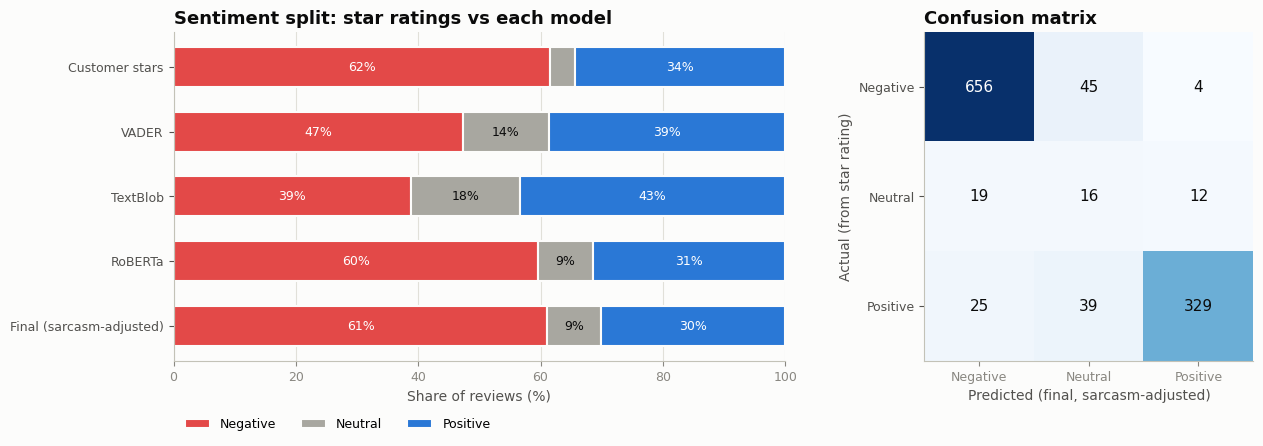


Classification report (final sentiment vs star-based label):
              precision    recall  f1-score   support

    Negative       0.94      0.93      0.93       705
     Neutral       0.16      0.34      0.22        47
    Positive       0.95      0.84      0.89       393

    accuracy                           0.87      1145
   macro avg       0.68      0.70      0.68      1145
weighted avg       0.91      0.87      0.89      1145



In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
left = np.zeros(len(dist))
y = np.arange(len(dist))[::-1]
for s in SENT_ORDER:
    ax.barh(y, dist[s].values, left=left, color=SENT_COLORS[s], height=0.62, label=s,
            edgecolor=SURFACE, linewidth=1.5)
    for yi, l, v in zip(y, left, dist[s].values):
        if v >= 6:
            ax.text(l + v / 2, yi, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                    color="white" if s != "Neutral" else INK)
    left += dist[s].values
ax.set_yticks(y)
ax.set_yticklabels(dist.index)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of reviews (%)")
ax.set_title("Sentiment split: star ratings vs each model", loc="left")
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.14))
ax.grid(axis="y", visible=False)

cm = confusion_matrix(df["star_sentiment"], df["final_sentiment"], labels=SENT_ORDER)
ax = axes[1]
ax.imshow(cm, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() * 0.55 else INK)
ax.set_xticks(range(3))
ax.set_xticklabels(SENT_ORDER)
ax.set_yticks(range(3))
ax.set_yticklabels(SENT_ORDER)
ax.set_xlabel("Predicted (final, sarcasm-adjusted)")
ax.set_ylabel("Actual (from star rating)")
ax.set_title("Confusion matrix", loc="left")
ax.grid(False)
save_show(fig, "sentiment_model_comparison")

print("\nClassification report (final sentiment vs star-based label):")
print(classification_report(df["star_sentiment"], df["final_sentiment"], labels=SENT_ORDER, zero_division=0))

  [chart saved] swiggy_project_outputs/fig03_sentiment_score_by_rating.png


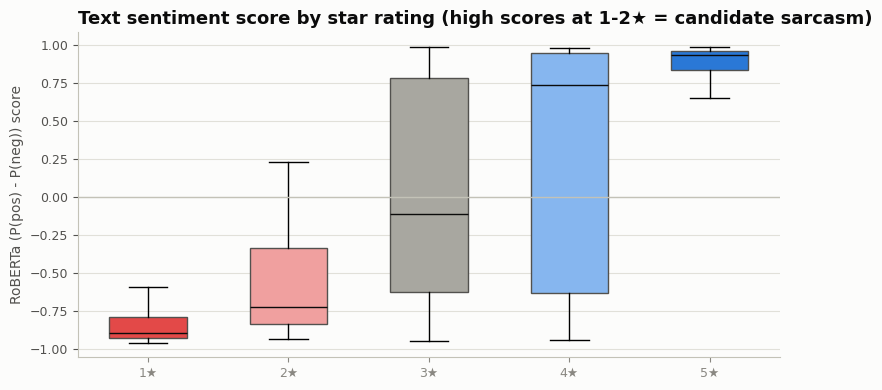

In [29]:
# Scores by star rating: a sanity check that model scores rise with the stars
fig, ax = plt.subplots(figsize=(8, 4))
score_col = "roberta_score" if HAS_ROBERTA else "vader_compound"
data = [df.loc[df["rating"] == s, score_col].values for s in [1, 2, 3, 4, 5]]
bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.55)
for patch, s in zip(bp["boxes"], [1, 2, 3, 4, 5]):
    patch.set_facecolor(STAR_COLORS[s])
    patch.set_edgecolor(INK2)
for med in bp["medians"]:
    med.set_color(INK)
ax.axhline(0, color=AXIS, lw=1)
ax.set_xticklabels([f"{s}★" for s in [1, 2, 3, 4, 5]])
ax.set_ylabel(f"{'RoBERTa (P(pos) - P(neg))' if HAS_ROBERTA else 'VADER compound'} score")
ax.set_title("Text sentiment score by star rating (high scores at 1-2★ = candidate sarcasm)", loc="left")
ax.grid(axis="x", visible=False)
save_show(fig, "sentiment_score_by_rating")

## 6. Feature extraction with TF-IDF

**TF-IDF = Term Frequency × Inverse Document Frequency.** A word scores high when it is frequent in *one* review but rare across *all* reviews: "food" appears everywhere (low weight), while "refund" or "cold" marks a specific issue (high weight).

| Setting | Value | Why |
|---|---|---|
| `ngram_range` | (1, 2) | single words and two-word phrases such as "platform fee" |
| `min_df` | at least 3 reviews | drops typos and one-off noise |
| `max_df` | 0.85 | drops terms found in more than 85% of reviews, which carry no information |
| `sublinear_tf` | True | uses 1 + log(tf), so one review repeating "worst" 10 times cannot dominate |

**TF-IDF is used four ways:**
- **(a)** the most important terms overall;
- **(b)** the terms that separate negative from positive reviews;
- **(c)** features for a **Logistic Regression** that predicts happy (4–5★) vs unhappy (1–2★) customers. Its coefficients show which words drive bad ratings. A Pipeline re-learns the vocabulary inside each cross-validation fold to avoid data leakage;
- **(d)** **NMF topic modelling** on negative reviews, to discover complaint themes without defining them in advance.

In [30]:
section("SECTION 6 - FEATURE EXTRACTION (TF-IDF)")

MIN_DF = max(3, int(0.002 * N))
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=MIN_DF, max_df=0.85, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df["clean_text"])
terms = np.array(tfidf.get_feature_names_out())
density = X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])
print(f"TF-IDF matrix: {X_tfidf.shape[0]:,} reviews x {X_tfidf.shape[1]:,} terms "
      f"(sparsity {1 - density:.2%}, min_df = {MIN_DF})")

mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_tfidf = pd.DataFrame({"term": terms, "mean_tfidf": mean_tfidf}).nlargest(20, "mean_tfidf")
print("\nTop 20 terms by average TF-IDF weight:")
print(top_tfidf.round(4).to_string(index=False))


SECTION 6 - FEATURE EXTRACTION (TF-IDF)
TF-IDF matrix: 1,145 reviews x 1,101 terms (sparsity 99.04%, min_df = 3)

Top 20 terms by average TF-IDF weight:
            term  mean_tfidf
            good      0.0706
        delivery      0.0443
           order      0.0434
         service      0.0433
             not      0.0418
            food      0.0365
            time      0.0300
           worst      0.0288
            best      0.0281
        customer      0.0261
            nice      0.0215
             bad      0.0209
              no      0.0206
      experience      0.0180
          charge      0.0172
            give      0.0161
         partner      0.0161
         deliver      0.0158
            fast      0.0148
delivery partner      0.0146


In [31]:
# (b) Distinctive terms: average TF-IDF in negative reviews minus positive ones
neg_mask = (df["final_sentiment"] == "Negative").values
pos_mask = (df["final_sentiment"] == "Positive").values
diff = np.asarray(X_tfidf[neg_mask].mean(axis=0)).ravel() - np.asarray(X_tfidf[pos_mask].mean(axis=0)).ravel()
distinct = pd.DataFrame({"term": terms, "neg_minus_pos": diff})
neg_terms = distinct.nlargest(12, "neg_minus_pos")
pos_terms = distinct.nsmallest(12, "neg_minus_pos")

In [32]:
# (c) TF-IDF + Logistic Regression: which words predict a bad rating?
# Target = the customer's own verdict (1-2 stars vs 4-5 stars). 3-star reviews
# are left out as ambiguous. We use a Pipeline so the TF-IDF vocabulary is
# re-learned inside each cross-validation fold, which avoids data leakage.
polar = df[df["rating"] != 3]
y_polar = (polar["rating"] >= 4).astype(int).values
lr_coef = None
if len(np.unique(y_polar)) == 2 and min(np.bincount(y_polar)) >= 5:
    pipe = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=MIN_DF, max_df=0.85, sublinear_tf=True),
                         LogisticRegression(max_iter=2000, class_weight="balanced", C=2.0))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(pipe, polar["clean_text"], y_polar, cv=cv, scoring=["accuracy", "f1_macro"])
    print(f"\nTF-IDF + Logistic Regression (5-fold CV) predicting happy (4-5★) vs unhappy (1-2★): "
          f"accuracy = {scores['test_accuracy'].mean():.1%}, macro-F1 = {scores['test_f1_macro'].mean():.3f}")
    pipe.fit(polar["clean_text"], y_polar)
    lr_terms = pipe.named_steps["tfidfvectorizer"].get_feature_names_out()
    lr_coef = pd.DataFrame({"term": lr_terms, "coef": pipe.named_steps["logisticregression"].coef_[0]})
    unhappy_terms = lr_coef.nsmallest(15, "coef")["term"].tolist()
    print("Words that most predict an UNHAPPY customer:", ", ".join(unhappy_terms))
    print("Words that most predict a HAPPY customer   :", ", ".join(lr_coef.nlargest(15, "coef")["term"]))
    # Positive words (in VADER's lexicon) that predict an unhappy customer are
    # a fingerprint of sarcasm, found by the data rather than by our rules.
    sarcastic_words = [t for t in unhappy_terms if " " not in t and vader.lexicon.get(t, 0) > 0]
    if sarcastic_words:
        print(f"  Note: positive words {sarcastic_words} predict UNHAPPY customers. They are used "
              "sarcastically, which independently supports Section 5.")


TF-IDF + Logistic Regression (5-fold CV) predicting happy (4-5★) vs unhappy (1-2★): accuracy = 90.7%, macro-F1 = 0.898
Words that most predict an UNHAPPY customer: not, worst, no, bad, order, support, fraud, poor, cancel, payment, never, waste, show, late, receive
Words that most predict a HAPPY customer   : good, best, nice, fast, excellent, thank, super, love, easy, great, discount, amaze, thanks, useful, wonderful
  Note: positive words ['support'] predict UNHAPPY customers. They are used sarcastically, which independently supports Section 5.


  [chart saved] swiggy_project_outputs/fig04_tfidf_features.png


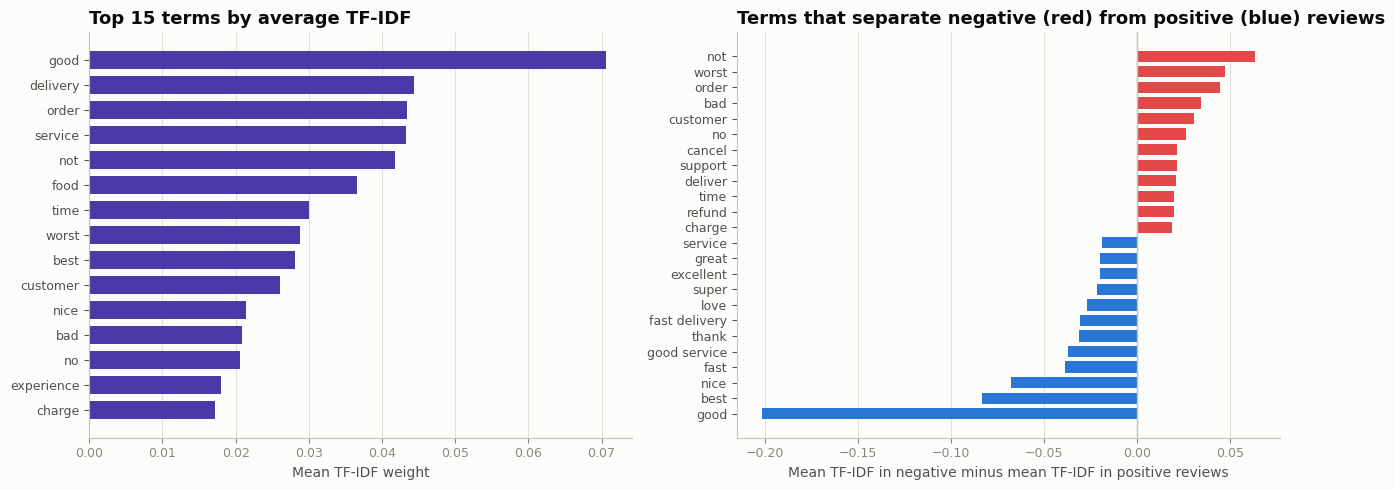

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
hbar(axes[0], top_tfidf["term"].tolist()[:15], top_tfidf["mean_tfidf"].values[:15], ACCENT,
     "Top 15 terms by average TF-IDF", "Mean TF-IDF weight")
both = pd.concat([neg_terms, pos_terms]).sort_values("neg_minus_pos")   # most negative-leaning on top
lab, val = both["term"].tolist(), both["neg_minus_pos"].tolist()
yy = np.arange(len(lab))
axes[1].barh(yy, val, color=[SENT_COLORS["Negative"] if v > 0 else SENT_COLORS["Positive"] for v in val],
             height=0.72)
axes[1].set_yticks(yy)
axes[1].set_yticklabels(lab)
axes[1].axvline(0, color=AXIS, lw=1)
axes[1].set_title("Terms that separate negative (red) from positive (blue) reviews", loc="left")
axes[1].set_xlabel("Mean TF-IDF in negative minus mean TF-IDF in positive reviews")
axes[1].grid(axis="y", visible=False)
save_show(fig, "tfidf_features")

In [34]:
# (d) Topic modelling on negative reviews: NMF on TF-IDF finds groups of words
# that appear together, i.e. complaint themes, without us defining them first.
# This checks the aspect dictionary used in Section 9 from the data side.
neg_docs = df.loc[neg_mask, "clean_text"]
nmf_topics = []
if len(neg_docs) >= 40:
    tf_neg = TfidfVectorizer(ngram_range=(1, 2), min_df=max(2, MIN_DF // 2), max_df=0.8, sublinear_tf=True)
    Xn = tf_neg.fit_transform(neg_docs)
    k = 6 if Xn.shape[1] > 60 else 3
    nmf = NMF(n_components=k, random_state=RANDOM_STATE, init="nndsvda", max_iter=500).fit(Xn)
    vocab = tf_neg.get_feature_names_out()
    print(f"\nNMF complaint themes discovered in {len(neg_docs):,} negative reviews:")
    for t, comp in enumerate(nmf.components_):
        top_words = [vocab[i] for i in comp.argsort()[::-1][:8]]
        nmf_topics.append(top_words)
        print(f"  Theme {t + 1}: {', '.join(top_words)}")


NMF complaint themes discovered in 700 negative reviews:
  Theme 1: order, not, food, deliver, time, cancel, no, refund
  Theme 2: worst, worst service, ever, worst ever, worst experience, experience, worst food, service
  Theme 3: bad, bad experience, experience, bad service, not, service bad, bad customer, bad quality
  Theme 4: delivery, partner, delivery partner, late, time, delivery time, late delivery, partner not
  Theme 5: service, customer, customer service, poor, pathetic, poor service, worst customer, pathetic customer
  Theme 6: high, charge, price, charge high, fee, delivery charge, gst, high price


## 7. Tri-gram analysis

Single words lose context: "delivery" says nothing, while "delivery partner rude" or "not receive refund" names the exact failure. Tri-grams (three-word sequences) surface these recurring phrases.

We compare negative and positive reviews and attach the **average star rating of the reviews containing each phrase**, so every phrase carries a measured satisfaction cost.

In [35]:
section("SECTION 7 - TRI-GRAM ANALYSIS")


def top_ngrams(texts, n=3, k=15, min_df=2):
    texts = texts[texts.str.split().str.len() >= n]
    if len(texts) < 5:
        return pd.DataFrame(columns=["ngram", "count"])
    cv_ = CountVectorizer(ngram_range=(n, n), min_df=min_df)
    try:
        X_ = cv_.fit_transform(texts)
    except ValueError:
        return pd.DataFrame(columns=["ngram", "count"])
    freq = np.asarray(X_.sum(axis=0)).ravel()
    return pd.DataFrame({"ngram": cv_.get_feature_names_out(), "count": freq}).nlargest(k, "count")


def avg_rating_with(phrase):
    padded = " " + df["clean_text"] + " "
    return df.loc[padded.str.contains(" " + phrase + " ", regex=False), "rating"].mean()


tri_all = top_ngrams(df["clean_text"])
tri_neg = top_ngrams(df.loc[neg_mask, "clean_text"])
tri_pos = top_ngrams(df.loc[pos_mask, "clean_text"])
for t in (tri_all, tri_neg, tri_pos):
    t["avg_rating"] = t["ngram"].apply(avg_rating_with).round(2)
print("Top tri-grams (all reviews):")
print(tri_all.to_string(index=False))
print("\nTop tri-grams in NEGATIVE reviews:")
print(tri_neg.to_string(index=False))
print("\nTop tri-grams in POSITIVE reviews:")
print(tri_pos.to_string(index=False))
pd.concat([tri_all.assign(segment="all"), tri_neg.assign(segment="negative"),
           tri_pos.assign(segment="positive")]).to_csv(os.path.join(OUTPUT_DIR, "04_trigrams.csv"), index=False)


SECTION 7 - TRI-GRAM ANALYSIS
Top tri-grams (all reviews):
                    ngram  count  avg_rating
     delivery partner not     21        1.10
    customer care service      7        1.57
        not deliver order      7        1.00
        order not deliver      7        1.00
   worst customer service      7        1.00
         food not deliver      6        1.00
 service delivery partner      6        1.50
       best food delivery      5        4.60
        customer care not      5        1.00
     customer support not      5        1.40
    delivery partner take      5        1.00
         not deliver time      5        1.20
   order delivery partner      5        1.00
pathetic customer service      5        1.60
           take order not      5        1.00

Top tri-grams in NEGATIVE reviews:
                    ngram  count  avg_rating
     delivery partner not     20        1.10
        not deliver order      7        1.00
        order not deliver      7        1.00
   w

  [chart saved] swiggy_project_outputs/fig05_trigrams.png


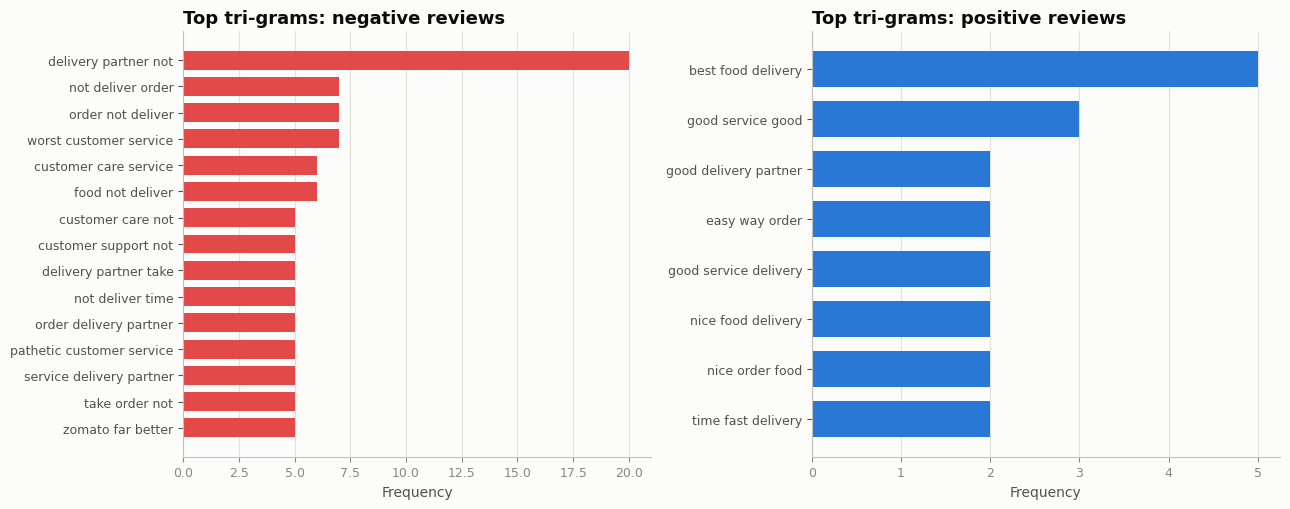

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
if len(tri_neg):
    hbar(axes[0], tri_neg["ngram"].tolist(), tri_neg["count"].values, SENT_COLORS["Negative"],
         "Top tri-grams: negative reviews", "Frequency")
if len(tri_pos):
    hbar(axes[1], tri_pos["ngram"].tolist(), tri_pos["count"].values, SENT_COLORS["Positive"],
         "Top tri-grams: positive reviews", "Frequency")
save_show(fig, "trigrams")

## 8. Unigram analysis and word clouds

Unigrams (single words) give the customer's broad vocabulary. A word cloud shows the same frequency table visually: the bigger the word, the more often it is mentioned.

We draw **three** clouds (all, negative and positive reviews), because a single overall cloud mixes praise and complaints and hides both. Colours follow the polarity used throughout: red = negative, blue = positive.


SECTION 8 - UNIGRAM ANALYSIS & WORD CLOUDS
Top 25 unigrams:
      word  count  share_of_reviews_%
     order    560                29.3
       not    480                28.6
  delivery    350                24.6
      food    300                18.8
  customer    248                15.9
   service    241                18.2
      time    235                15.5
     worst    185                14.2
      good    183                14.4
        no    151                10.8
   deliver    120                 8.2
experience    115                 8.8
   partner    113                 8.0
   support    106                 8.0
    charge    104                 7.3
    refund     99                 7.4
      give     97                 7.2
      item     92                 6.2
       bad     92                 6.8
    cancel     91                 6.9
      hour     86                 6.7
      take     84                 7.0
    minute     82                 4.9
   receive     70          

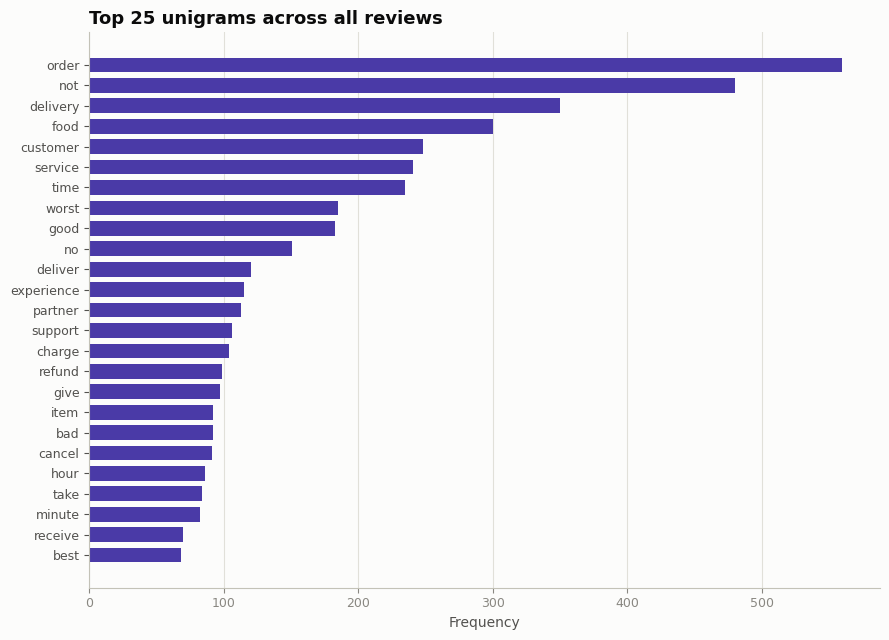

In [37]:
section("SECTION 8 - UNIGRAM ANALYSIS & WORD CLOUDS")


def unigram_freq(texts):
    return Counter(w for t in texts for w in t.split())


uni_all = unigram_freq(df["clean_text"])
uni_neg = unigram_freq(df.loc[neg_mask, "clean_text"])
uni_pos = unigram_freq(df.loc[pos_mask, "clean_text"])
uni_table = pd.DataFrame(uni_all.most_common(25), columns=["word", "count"])
uni_table["share_of_reviews_%"] = uni_table["word"].apply(
    lambda w: round((" " + df["clean_text"] + " ").str.contains(f" {w} ", regex=False).mean() * 100, 1))
print("Top 25 unigrams:")
print(uni_table.to_string(index=False))
uni_table.to_csv(os.path.join(OUTPUT_DIR, "05_unigrams.csv"), index=False)
print("\nTop negative-review words:", ", ".join(w for w, _ in uni_neg.most_common(15)))
print("Top positive-review words:", ", ".join(w for w, _ in uni_pos.most_common(15)))

fig, ax = plt.subplots(figsize=(9, 6.5))
hbar(ax, uni_table["word"].tolist(), uni_table["count"].values, ACCENT,
     "Top 25 unigrams across all reviews", "Frequency")
save_show(fig, "unigrams")

In [38]:
def cloud_color(cmap_name):
    """Colour words by size on one hue (light = rare, dark = frequent), with
    the lightest shades removed so small words stay readable on white."""
    cmap = matplotlib.colormaps[cmap_name]

    def color_func(word, font_size, position, orientation, random_state=None, **kw):
        r, g, b, _ = cmap(0.45 + 0.55 * min(font_size / 110, 1))
        return f"rgb({int(r * 255)}, {int(g * 255)}, {int(b * 255)})"
    return color_func

  [chart saved] swiggy_project_outputs/fig07_wordclouds.png


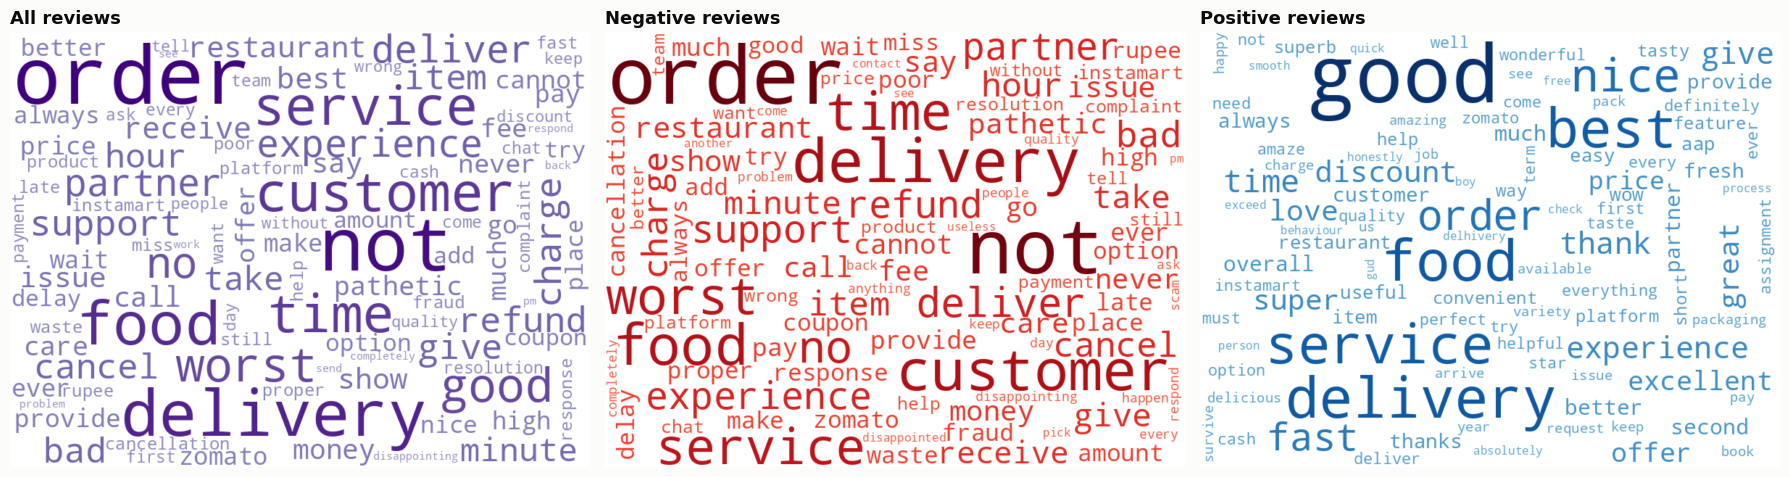

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, freq, cmap, title in [(axes[0], uni_all, "Purples", "All reviews"),
                              (axes[1], uni_neg, "Reds", "Negative reviews"),
                              (axes[2], uni_pos, "Blues", "Positive reviews")]:
    ax.axis("off")
    ax.set_title(title, loc="left")
    if freq:
        wc = WordCloud(width=800, height=600, background_color="white", max_words=100, max_font_size=110,
                       collocations=False, random_state=RANDOM_STATE,
                       color_func=cloud_color(cmap)).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation="bilinear")
save_show(fig, "wordclouds")

## 9. Aspect-based sentiment: what exactly drives the sentiment?

Overall sentiment tells management *how* customers feel; aspect analysis tells them *why*. Each review is tagged with the business aspects it mentions, using a keyword dictionary built from Swiggy's value chain (delivery time, delivery partner, refunds and support, pricing and fees, offers, order accuracy and food quality, app and payments, cancellation, Swiggy One, Instamart, restaurant variety). The dictionary is cross-checked against the unsupervised NMF themes in Section 10.

| Metric | Meaning |
|---|---|
| Mention share | how many customers talk about the aspect (volume) |
| % negative | how badly it performs when they do (severity) |
| NSS | Net Sentiment Score = % positive − % negative |
| **Pain score** | mention share × % negative (volume × severity), used to rank priorities |
| % sarcastic | where customers are so frustrated that they turn sarcastic |

We also look at the most "helpful"-voted negative reviews (the Play Store shows these first to every prospective user), the share of negative reviews over time, and sentiment by app version.

In [50]:
ASPECTS = {
    "Delivery time": r"\b(late|delay\w*|on time|in time|delivery time|long time|took (so |too )?long|minutes"
                     r"|minute|hours?|wait\w*|eta|slow|fast|quick\w*|early|speed\w*|superfast|timely)\b",
    "Delivery partner": r"\b(delivery partner|rider|riders|driver|drivers)\b",
    "Refund & customer support": r"\b(refund\w*|money back|customer (care|support|service)|support|helpline"
                                 r"|chat\w*|complain\w*|executive|agent|bot|resol\w*|escalat\w*|help centre)\b",
    "Pricing & fees": r"\b(price\w*|pricing|expensive|costly|cost\w*|charg\w*|fees?|surge|gst|tax\w*"
                      r"|overpric\w*|hike\w*|mrp|afford\w*|rupees)\b",
    "Offers & discounts": r"\b(offers?|discounts?|coupons?|cashback|deals?|promo\w*|vouchers?)\b",
    "Order accuracy & food quality": r"\b(wrong|missing|not (received|delivered)|never (received|delivered)"
                                     r"|cold|stale|spill\w*|leak\w*|quality|taste\w*|tasty|quantity|fresh\w*"
                                     r"|damaged|packag\w*|hygien\w*|raw|burnt|rotten|hair|insect)\b",
    "App & payments": r"\b(crash\w*|bug\w*|glitch\w*|updat\w*|login|log in|otp|payment\w*|upi|card"
                      r"|wallet|interface|ui|loading|error|server|gps|location|address|track\w*|notification\w*"
                      r"|not working)\b",
    "Cancellation": r"\b(cancel\w*)\b",
    "Swiggy One membership": r"\b(swiggy one|one lite|membership|member|subscription|subscri\w*)\b",
    "Instamart & grocery": r"\b(instamart|grocer\w*|vegetables?|fruits?|milk|dairy|out of stock|expir\w*)\b",
    "Restaurant choice & variety": r"\b(restaurants?|variety|options?|choices?|menu|dishes|cuisines?|selection)\b",
}

rows = []
for aspect, pattern in ASPECTS.items():
    m = df["norm_text"].str.contains(pattern, regex=True)
    df[f"asp_{aspect}"] = m
    sub = df[m]
    if len(sub) == 0:
        continue
    pct_neg = (sub["final_sentiment"] == "Negative").mean() * 100
    pct_pos = (sub["final_sentiment"] == "Positive").mean() * 100
    rows.append({"aspect": aspect, "mentions": len(sub), "mention_pct": len(sub) / N * 100,
                 "neg_pct": pct_neg, "pos_pct": pct_pos, "NSS": pct_pos - pct_neg,
                 "avg_rating": sub["rating"].mean(), "sarcastic_pct": sub["is_sarcastic"].mean() * 100,
                 "helpful_votes": int(sub["helpful_votes"].sum())})
aspects = pd.DataFrame(rows)
aspects["pain_score"] = aspects["mention_pct"] * aspects["neg_pct"] / 100
aspects = aspects.sort_values("pain_score", ascending=False).reset_index(drop=True)
print(aspects.round(1).to_string(index=False))
aspects.round(2).to_csv(os.path.join(OUTPUT_DIR, "06_aspect_sentiment.csv"), index=False)
no_aspect = (~df[[c for c in df.columns if c.startswith("asp_")]].any(axis=1)).mean()
print(f"Reviews mentioning at least one aspect: {1 - no_aspect:.0%}")

                       aspect  mentions  mention_pct  neg_pct  pos_pct    NSS  avg_rating  sarcastic_pct  helpful_votes  pain_score
    Refund & customer support       247         21.6     97.2      1.2  -96.0         1.1            2.4             53        21.0
                Delivery time       237         20.7     78.5     15.2  -63.3         1.9            2.5             47        16.2
               Pricing & fees       178         15.5     78.7     11.8  -66.9         1.8            2.8            239        12.2
Order accuracy & food quality       142         12.4     85.9     12.0  -73.9         1.5            4.2             23        10.7
                 Cancellation        97          8.5     94.8      1.0  -93.8         1.1            4.1             19         8.0
  Restaurant choice & variety       100          8.7     85.0     11.0  -74.0         1.6            3.0             41         7.4
             Delivery partner        93          8.1     89.2      7.5  -81.

  [chart saved] swiggy_project_outputs/fig08_aspect_sentiment.png


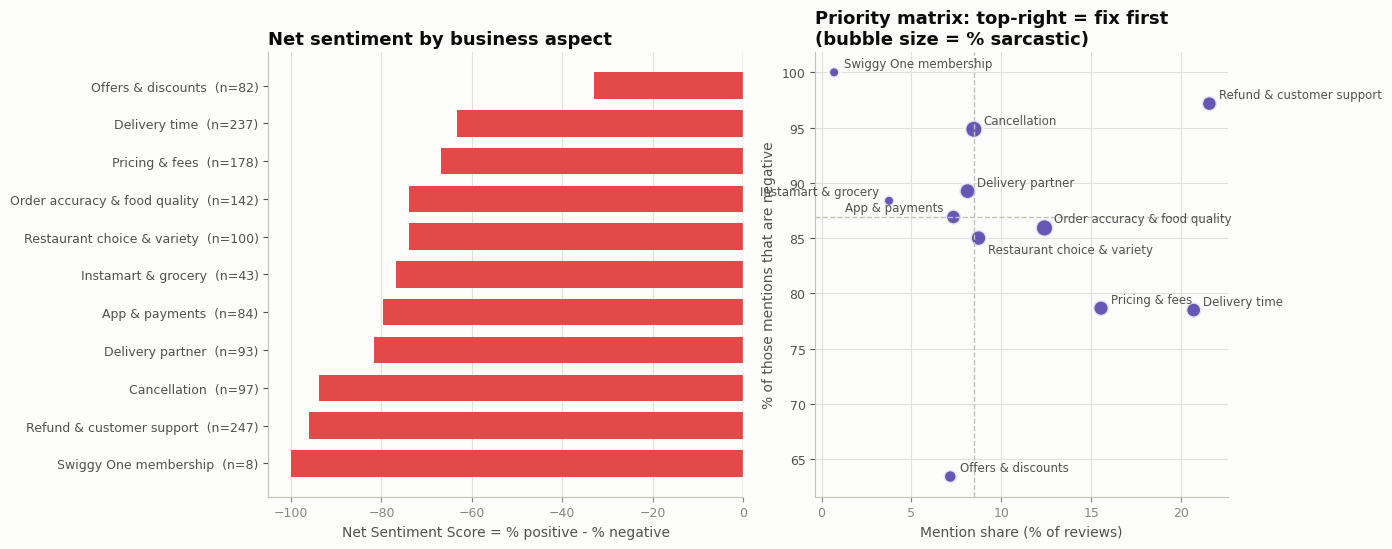

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.15, 1]})
a = aspects.sort_values("NSS")
y = np.arange(len(a))
axes[0].barh(y, a["NSS"], color=[SENT_COLORS["Negative"] if v < 0 else SENT_COLORS["Positive"] for v in a["NSS"]],
             height=0.7)
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{r.aspect}  (n={r.mentions})" for r in a.itertuples()])
axes[0].axvline(0, color=AXIS, lw=1)
axes[0].set_xlabel("Net Sentiment Score = % positive - % negative")
axes[0].set_title("Net sentiment by business aspect", loc="left")
axes[0].grid(axis="y", visible=False)

ax = axes[1]
ax.scatter(aspects["mention_pct"], aspects["neg_pct"], s=60 + aspects["sarcastic_pct"] * 25,
           color=ACCENT, alpha=0.85, edgecolor=SURFACE, linewidth=2)

# Place each label at the first nearby position that does not collide with
# an already-placed label, so clustered points stay readable.
fig.canvas.draw()
placed = []
for r in aspects.sort_values("mention_pct", ascending=False).itertuples():
    for dx, dy, ha in [(7, 4, "left"), (7, -11, "left"), (-7, 4, "right"), (-7, -11, "right"),
                       (7, 15, "left"), (7, -22, "left"), (-7, 15, "right"), (-7, -22, "right")]:
        t = ax.annotate(r.aspect, (r.mention_pct, r.neg_pct), xytext=(dx, dy), textcoords="offset points",
                        fontsize=8.5, color=INK2, ha=ha)
        bb = t.get_window_extent(renderer=fig.canvas.get_renderer()).expanded(1.05, 1.15)
        if not any(bb.overlaps(p) for p in placed):
            placed.append(bb)
            break
        t.remove()
    else:
        placed.append(ax.annotate(r.aspect, (r.mention_pct, r.neg_pct), xytext=(7, 4), textcoords="offset points",
                                  fontsize=8.5, color=INK2).get_window_extent(renderer=fig.canvas.get_renderer()))
ax.axvline(aspects["mention_pct"].median(), color=AXIS, ls="--", lw=1)
ax.axhline(aspects["neg_pct"].median(), color=AXIS, ls="--", lw=1)
ax.set_xlabel("Mention share (% of reviews)")
ax.set_ylabel("% of those mentions that are negative")
ax.set_title("Priority matrix: top-right = fix first\n(bubble size = % sarcastic)", loc="left")
save_show(fig, "aspect_sentiment")

In [42]:
# Most-endorsed complaints: the Play Store lists reviews with the most
# "helpful" votes first, so these are what prospective users read before
# installing. They carry the most marketing weight.
top_helpful = df[df["final_sentiment"] == "Negative"].nlargest(5, "helpful_votes")
print("\nMost 'helpful'-voted negative reviews (visible to every new user):")
for _, r in top_helpful.iterrows():
    print(f"  [{r['rating']}★, {r['helpful_votes']} votes] {short(r['review'], 160)}")


Most 'helpful'-voted negative reviews (visible to every new user):
  [4★, 51 votes] good food delivery app but it charges over 17 bucks for it's fee on an order
  [1★, 20 votes] Instamart is seriously robbing custoners. They have handlling fee, delivery fee and high demand surge fee....all together works out to be costlier than the p...
  [1★, 19 votes] I don't f understand why swiggy removed the schedule option I'm literally pissed off. Suppose i wanna eat the food at 11pm I don't get to see the offers whic...
  [3★, 6 votes] instamart support is a little iffy and unhelpful. And there's the issue of inflated prices. Otherwise a good app.
  [2★, 5 votes] If I order 10 kg weighing items, worth 1500Rs, the delivery guy still shows with a single torn paper bag asking me to bring my own bag. Can't you send an ext...


  [chart saved] swiggy_project_outputs/fig09_negative_trend.png


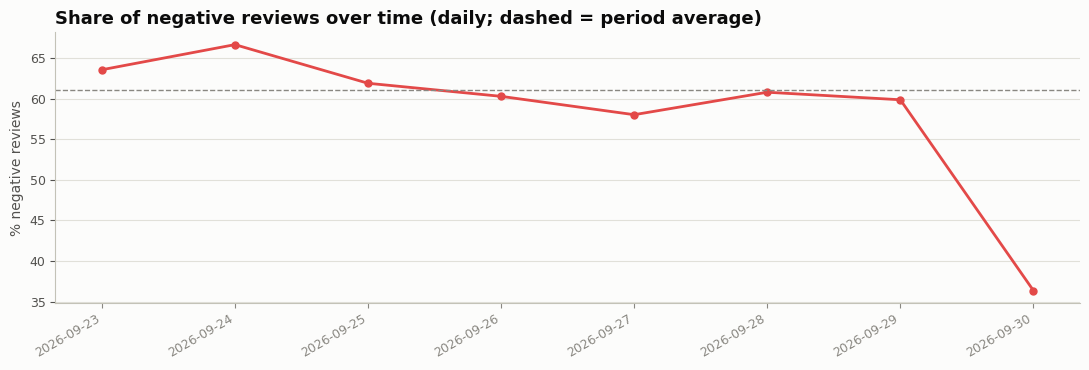

In [43]:
# Sentiment trend over time
trend = None
if df["review_date"].notna().sum() > 30:
    span_days = (date_max - date_min).days
    freq = "D" if span_days <= 31 else ("W" if span_days <= 180 else "MS")
    trend = df.dropna(subset=["review_date"]).set_index("review_date").resample(freq).agg(
        reviews=("final_sentiment", "size"),
        pct_negative=("final_sentiment", lambda s: (s == "Negative").mean() * 100))
    trend = trend[trend["reviews"] >= 10]
    if len(trend) >= 3:
        fig, ax = plt.subplots(figsize=(11, 3.8))
        ax.plot(trend.index, trend["pct_negative"], color=SENT_COLORS["Negative"], lw=2, marker="o", ms=5)
        ax.axhline((df["final_sentiment"] == "Negative").mean() * 100, color=MUTED, ls="--", lw=1)
        ax.set_ylabel("% negative reviews")
        period = {"D": "daily", "W": "weekly", "MS": "monthly"}[freq]
        ax.set_title(f"Share of negative reviews over time ({period}; dashed = period average)", loc="left")
        ax.grid(axis="x", visible=False)
        fig.autofmt_xdate()
        save_show(fig, "negative_trend")

In [44]:
# App versions: do some releases produce more negative reviews?
ver = df.dropna(subset=["app_version"]).groupby("app_version").agg(
    reviews=("rating", "size"), avg_rating=("rating", "mean"),
    pct_negative=("final_sentiment", lambda s: (s == "Negative").mean() * 100))
ver = ver[ver["reviews"] >= 30].sort_values("reviews", ascending=False).head(6)
if len(ver) >= 2:
    print("\nSentiment by app version (versions with 30+ reviews):")
    print(ver.round(1).to_string())


Sentiment by app version (versions with 30+ reviews):
             reviews  avg_rating  pct_negative
app_version                                   
4.116.2          486         2.4          61.5
4.117.0          323         2.9          49.5
4.115.0           42         2.6          64.3


## 10. Interpretation of results

The findings below are **generated from the numbers computed above**, not typed in by hand, so they stay correct whenever the data is refreshed.

In [45]:
import pandas as pd
import os

# Ensure OUTPUT_DIR is defined, typically from config cell 82b16e7c
if 'OUTPUT_DIR' not in globals():
    OUTPUT_DIR = "swiggy_project_outputs" # Fallback if not defined, though it should be

# Ensure SENT_ORDER is defined, typically from plotting style cell 78761c6f
if 'SENT_ORDER' not in globals():
    SENT_ORDER = ["Negative", "Neutral", "Positive"] # Fallback

# Ensure df is available, load from scored CSV if not in scope.
# This CSV is generated at the very end of the previous successful run.
if 'df' not in globals():
    scored_csv_path = os.path.join(OUTPUT_DIR, "08_swiggy_reviews_scored.csv")
    if os.path.exists(scored_csv_path):
        print(f"Loading 'df' from {scored_csv_path} as it's not defined.")
        df = pd.read_csv(scored_csv_path)
        # Ensure review_date and reply_date are datetime objects if needed downstream
        df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
        df["reply_date"] = pd.to_datetime(df["reply_date"], errors="coerce")
        # Ensure rating is int if needed
        df["rating"] = pd.to_numeric(df["rating"], errors="coerce").fillna(0).astype(int)
        # Ensure 'has_reply' is boolean, it's created in eda section `6f09c060` but might not be saved as bool
        # Recreate based on 'company_reply' which should be in the scored CSV
        if 'has_reply' not in df.columns:
            df["has_reply"] = df["company_reply"].notna() & (df["company_reply"].astype(str).str.strip() != "")
    else:
        raise RuntimeError(f"DataFrame 'df' is not defined and could not be loaded from {scored_csv_path}. "
                           "Please run the entire notebook from the beginning.")

# Ensure 'aspects' DataFrame is available as it's used in this cell.
# 'aspects' is created in cell 0f998e5a. If df was undefined, 'aspects' also would be.
# The `06_aspect_sentiment.csv` contains the `aspects` dataframe.
if 'aspects' not in globals():
    aspect_csv_path = os.path.join(OUTPUT_DIR, "06_aspect_sentiment.csv")
    if os.path.exists(aspect_csv_path):
        print(f"Loading 'aspects' from {aspect_csv_path} as it's not defined.")
        aspects = pd.read_csv(aspect_csv_path)
    else:
        raise RuntimeError(f"DataFrame 'aspects' is not defined and could not be loaded from {aspect_csv_path}. "
                           "Please ensure previous cells creating 'aspects' were run or run the entire notebook.")

share = df["final_sentiment"].value_counts(normalize=True).reindex(SENT_ORDER, fill_value=0) * 100
literal_share = df["literal_sentiment"].value_counts(normalize=True).reindex(SENT_ORDER, fill_value=0) * 100
NSS = share["Positive"] - share["Negative"]
top_pain = aspects.head(3)
strengths = aspects[aspects["mention_pct"] >= 3].sort_values("NSS", ascending=False).head(2)
most_sarcastic = aspects[aspects["mentions"] >= 20].sort_values("sarcastic_pct", ascending=False).head(1)
neg_reply_rate = df.loc[df["rating"] <= 2, "has_reply"].mean() * 100

In [46]:
asp_cols = [c for c in df.columns if c.startswith("asp_")]
aspects_per_review = df.groupby("final_sentiment")[asp_cols].sum().sum(axis=1) / df["final_sentiment"].value_counts()
store = APP_INFO.get("score")
store_txt = f" ({store:.1f})" if isinstance(store, (int, float)) else ""
short_note = (f" Detailed reviews skew negative: the very short reviews removed in Section 2 averaged "
              f"{too_short['rating'].mean():.1f} stars vs {df['rating'].mean():.1f} for the reviews analysed. Happy "
              f"customers often just write 'good', so the overall Play Store rating{store_txt} looks better than "
              f"the tone of written feedback."
              if len(too_short) and too_short["rating"].mean() > df["rating"].mean() else "")

insights = [
    f"1. OVERALL MOOD: After sarcasm correction, {share['Negative']:.0f}% of the {N:,} analysed reviews are "
    f"negative, {share['Neutral']:.0f}% neutral and {share['Positive']:.0f}% positive. That gives a Net "
    f"Sentiment Score of {NSS:+.0f} (average rating {df['rating'].mean():.2f} stars)." + short_note,

    f"2. MODEL CHOICE: {BEST_MODEL} agreed best with the customers' own star ratings "
    f"(macro-F1 {model_eval.loc[0, 'Macro_F1']:.2f} vs {model_eval['Macro_F1'].iloc[-1]:.2f} for the weakest). "
    + ("A context-aware transformer beats word-counting lexicons on real customer language. "
       if BEST_MODEL == "RoBERTa" else "")
    + "Lexicon models score each word on its own, so long reviews that mix complaints and praise confuse them.",

    f"3. HIDDEN NEGATIVITY (SARCASM): {n_sarc:,} reviews ({n_sarc / N:.1%}) are sarcastic. The literal model "
    f"would have counted {literal_share['Negative']:.0f}% as negative; the corrected figure is "
    f"{share['Negative']:.0f}%. A basic social-listening tool would under-report customer anger by "
    f"{share['Negative'] - literal_share['Negative']:.1f} percentage points."
    + (f" Sarcasm is most concentrated in '{most_sarcastic.iloc[0]['aspect']}' "
       f"({most_sarcastic.iloc[0]['sarcastic_pct']:.0f}% of its mentions). Customers are most exasperated here."
       if len(most_sarcastic) else ""),

    "4. BIGGEST PAIN POINTS (volume x severity): " + "; ".join(
        f"{r.aspect} (mentioned in {r.mention_pct:.0f}% of reviews, {r.neg_pct:.0f}% negative)" for r in top_pain.itertuples())
    + ". Fixing these gives the largest improvement in overall sentiment.",

    "5. STRENGTHS TO PROMOTE: " + ("; ".join(
        f"{r.aspect} (NSS {r.NSS:+.0f})" for r in strengths.itertuples()) if len(strengths) else "n/a")
    + ". These are the relatively best-rated parts of the experience and can lead marketing messages.",

    "6. WHAT THE N-GRAMS SAY: the most common negative tri-grams are "
    + ", ".join(f"'{g}'" for g in tri_neg["ngram"].head(4)) + ". Positive tri-grams centre on "
    + ", ".join(f"'{g}'" for g in tri_pos["ngram"].head(3))
    + f". On average a negative review names {aspects_per_review.get('Negative', 0):.1f} business aspects and a "
      f"positive one {aspects_per_review.get('Positive', 0):.1f}. "
    + ("Complaints are more specific than praise: customers explain exactly what failed, so each "
       "complaint doubles as a free operational diagnosis."
       if aspects_per_review.get("Negative", 0) > aspects_per_review.get("Positive", 0) else
       "Praise is as specific as criticism, so customers can clearly tell what Swiggy does well."),

    f"7. RESPONSE GAP: Swiggy publicly replied to {neg_reply_rate:.0f}% of 1-2 star reviews in this sample. "
    "Every unanswered complaint stays visible to future users without a brand response.",
]
if nmf_topics:
    # Cross-check: does each unsupervised NMF theme map onto one of our predefined aspects?
    theme_map = []
    for words in nmf_topics:     # assign each theme to the aspect that matches most of its top words
        votes = {a: sum(bool(re.search(pat, w)) for w in words) for a, pat in ASPECTS.items()}
        best = max(votes, key=votes.get)
        theme_map.append(best if votes[best] > 0 else None)
    matched = sum(h is not None for h in theme_map)
    unmapped = [", ".join(w[:3]) for w, h in zip(nmf_topics, theme_map) if h is None]
    insights.append(
        f"8. DATA-DRIVEN CHECK: NMF topic modelling (unsupervised, on TF-IDF of negative reviews) found "
        f"{len(nmf_topics)} complaint themes. {matched} of them map onto the predefined aspects ("
        + "; ".join(f"'{', '.join(w[:3])}' -> {h}" for w, h in zip(nmf_topics, theme_map) if h) + "). "
        + ("So the aspect dictionary covers what customers actually complain about."
           if not unmapped else f"Unmapped theme(s) worth a manual look: {' | '.join(unmapped)}."))
for line in insights:
    print("\n".join(textwrap.wrap(line, 100, subsequent_indent="   ")) + "\n")

1. OVERALL MOOD: After sarcasm correction, 61% of the 1,145 analysed reviews are negative, 9%
   neutral and 30% positive. That gives a Net Sentiment Score of -31 (average rating 2.45 stars).
   Detailed reviews skew negative: the very short reviews removed in Section 2 averaged 4.2 stars vs
   2.4 for the reviews analysed. Happy customers often just write 'good', so the overall Play Store
   rating (4.5) looks better than the tone of written feedback.

2. MODEL CHOICE: RoBERTa agreed best with the customers' own star ratings (macro-F1 0.67 vs 0.52 for
   the weakest). A context-aware transformer beats word-counting lexicons on real customer language.
   Lexicon models score each word on its own, so long reviews that mix complaints and praise confuse
   them.

3. HIDDEN NEGATIVITY (SARCASM): 24 reviews (2.1%) are sarcastic. The literal model would have
   counted 60% as negative; the corrected figure is 61%. A basic social-listening tool would under-
   report customer anger by 1.6 per

## 11. Strategic recommendations for Swiggy

Recommendations follow from the data. The top pain points are ranked by pain score, and each gets a concrete playbook plus a **KPI**, so every action is tied to a finding and to a way of measuring whether it worked. Four cross-cutting strategies follow: sarcasm-aware social listening, a review-response programme, leading marketing with strengths, and a monthly Voice-of-Customer KPI.

Everything is also saved to `swiggy_project_outputs/07_insights_and_strategy_report.txt`.

In [47]:
PLAYBOOK = {
    "Delivery time": (
        "Promise realistic ETAs (under-promise, over-deliver): a missed ETA is a very visible broken promise. "
        "Send proactive delay alerts and give automatic compensation (e.g. a coupon) when the ETA is missed by "
        "more than 10 minutes. Add riders at peak hours in the worst pin codes.",
        "% orders within promised ETA; share of delay-related negative reviews"),
    "Delivery partner": (
        "Run etiquette and handling training for delivery partners, with incentives linked to customer "
        "ratings. Require OTP or photo proof of delivery to stop 'marked delivered but not received'. "
        "Add a one-tap rider feedback prompt after each order.",
        "Rider rating; 'not received' complaint rate"),
    "Refund & customer support": (
        "Guarantee a human agent within 2 chatbot turns. Give instant, fraud-scored refunds for low-value "
        "missing or damaged items. Show refund status in the app with a timeline. Track first-contact "
        "resolution.",
        "First-contact resolution %; refund turnaround time; support NSS"),
    "Pricing & fees": (
        "Show every fee (platform, packaging, delivery, surge, GST) before checkout, not at the last step. "
        "Communicate the value of the fees and A/B-test fee bundling. Cap fees for Swiggy One members so "
        "the membership feels worth it.",
        "Checkout abandonment; fee-related complaint share"),
    "Offers & discounts": (
        "Fix coupon failures and state offer terms clearly. Offers that fail at checkout feel like "
        "bait-and-switch. Move budget from blanket discounts to personalised win-back offers for "
        "customers who post negative reviews.",
        "Coupon failure rate; win-back reorder rate"),
    "Order accuracy & food quality": (
        "Give restaurant partners a quality scorecard (wrong or missing items, spills). Make tamper-proof, "
        "spill-proof packaging the standard. Accept photo-based missing-item claims. Warn and then de-rank "
        "repeat offenders.",
        "Order-accuracy rate; missing-item claims per 1,000 orders"),
    "App & payments": (
        "Prioritise crash, payment and location bugs in release QA. Use staged rollouts and watch review "
        "sentiment by app version. Auto-refund failed payments with a visible status.",
        "Crash-free sessions; payment failure rate; NSS by app version"),
    "Cancellation": (
        "Sync restaurant availability in real time to prevent post-order cancellations. Give instant "
        "refunds and an apology credit when Swiggy or the restaurant cancels.",
        "Cancellation rate (non-customer initiated)"),
    "Swiggy One membership": (
        "Add a 'You saved Rs X this month' dashboard. Make sure the free-delivery promise is not eroded by "
        "other fees. Send targeted renewal nudges that show actual savings.",
        "Membership renewal rate; member NSS"),
    "Instamart & grocery": (
        "Improve inventory accuracy so items do not go out of stock after the order is placed. Offer a "
        "freshness guarantee with no-questions refunds. Add a substitute-approval flow.",
        "Fill rate; freshness complaints"),
    "Restaurant choice & variety": (
        "Use variety and choice as the lead message in campaigns and store listing (ASO). Onboard popular "
        "local restaurants in cities where 'options' complaints appear.",
        "Search-to-order conversion; restaurant coverage"),
}

In [48]:
strategies = []
for i, r in enumerate(top_pain.itertuples(), 1):
    action, kpi = PLAYBOOK.get(r.aspect, ("Investigate root causes with the operations team.", "Aspect NSS"))
    strategies.append(f"S{i}. FIX '{r.aspect.upper()}' (pain score {r.pain_score:.1f}, {r.neg_pct:.0f}% negative): "
                      f"{action}  KPI: {kpi}.")
n = len(strategies)
strategies += [
    f"S{n + 1}. SARCASM-AWARE SOCIAL LISTENING: {n_sarc / N:.1%} of reviews are sarcastic and would be misread as "
    "praise by standard tools. Brand-monitoring dashboards (Play Store, X/Twitter, Instagram) should combine a "
    "sentiment model with an irony model and a rating-text incongruity check, as done here.",
    f"S{n + 2}. REVIEW RESPONSE PROGRAMME: raise the public reply rate on 1-2 star reviews from "
    f"{neg_reply_rate:.0f}% to 100% within 24 hours, starting with the most helpful-voted reviews. Use a "
    "personalised resolution, not a template. Public replies show prospective users that Swiggy listens.",
    "S{0}. LEAD MARKETING WITH STRENGTHS: build campaigns and store-listing copy around ".format(n + 3)
    + (", ".join(f"'{r.aspect}'" for r in strengths.itertuples()) if len(strengths) else "the best-rated aspects")
    + f". Do not headline the weakest aspect ('{top_pain.iloc[0]['aspect']}') in advertising until "
      "operations back it up. Promising what customers do not experience is what turns disappointment "
      "into sarcasm.",
    f"S{n + 4}. TRACK A VOICE-OF-CUSTOMER KPI: re-run this pipeline monthly and report Net Sentiment Score "
    f"(currently {NSS:+.0f}) overall and by aspect. Set targets for the top pain points and link them to "
    "operations team OKRs.",
]
for s in strategies:
    print("\n".join(textwrap.wrap(s, 100, subsequent_indent="    ")) + "\n")

S1. FIX 'REFUND & CUSTOMER SUPPORT' (pain score 21.0, 97% negative): Guarantee a human agent within
    2 chatbot turns. Give instant, fraud-scored refunds for low-value missing or damaged items. Show
    refund status in the app with a timeline. Track first-contact resolution.  KPI: First-contact
    resolution %; refund turnaround time; support NSS.

S2. FIX 'DELIVERY TIME' (pain score 16.2, 78% negative): Promise realistic ETAs (under-promise,
    over-deliver): a missed ETA is a very visible broken promise. Send proactive delay alerts and
    give automatic compensation (e.g. a coupon) when the ETA is missed by more than 10 minutes. Add
    riders at peak hours in the worst pin codes.  KPI: % orders within promised ETA; share of delay-
    related negative reviews.

S3. FIX 'PRICING & FEES' (pain score 12.2, 79% negative): Show every fee (platform, packaging,
    delivery, surge, GST) before checkout, not at the last step. Communicate the value of the fees
    and A/B-test fee bund

In [51]:
# ---- Save the final report and scored dataset -------------------------------
report_path = os.path.join(OUTPUT_DIR, "07_insights_and_strategy_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(f"SWIGGY - SARCASM-AWARE SENTIMENT ANALYSIS OF PLAY STORE REVIEWS\n{'=' * 70}\n")
    f.write(f"Reviews analysed: {N:,}   Best sentiment model: {BEST_MODEL}   "
            f"Sarcastic reviews: {n_sarc:,} ({n_sarc / N:.1%})\n\n")
    f.write("MODEL EVALUATION (vs star ratings)\n" + model_eval.round(3).to_string(index=False) + "\n\n")
    f.write("ASPECT-LEVEL SENTIMENT\n" + aspects.round(1).to_string(index=False) + "\n\n")
    f.write("INTERPRETATION\n" + "\n\n".join(insights) + "\n\nSTRATEGIC RECOMMENDATIONS\n" + "\n\n".join(strategies))

export_cols = ["reviewId", "review_date", "rating", "review", "clean_text", "star_sentiment", "vader_compound",
               "vader_sentiment", "textblob_polarity", "textblob_subjectivity", "textblob_sentiment"]
export_cols += ["roberta_score", "roberta_sentiment"] if HAS_ROBERTA else []
export_cols += ["literal_sentiment", "irony_prob", "is_sarcastic", "final_sentiment", "helpful_votes"]
export_cols += [c for c in df.columns if c.startswith("asp_")]
df[export_cols].to_csv(os.path.join(OUTPUT_DIR, "08_swiggy_reviews_scored.csv"), index=False)


print(f"All charts, CSVs and the insights report are saved in: {os.path.abspath(OUTPUT_DIR)}")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    print("  -", fname)

All charts, CSVs and the insights report are saved in: /content/swiggy_project_outputs
  - 01_swiggy_reviews_raw.csv
  - 02_swiggy_reviews_clean.csv
  - 03_sarcastic_reviews.csv
  - 04_trigrams.csv
  - 05_unigrams.csv
  - 06_aspect_sentiment.csv
  - 07_insights_and_strategy_report.txt
  - 08_swiggy_reviews_scored.csv
  - fig01_eda_ratings_and_length.png
  - fig02_sentiment_model_comparison.png
  - fig03_sentiment_score_by_rating.png
  - fig04_tfidf_features.png
  - fig05_trigrams.png
  - fig06_unigrams.png
  - fig07_wordclouds.png
  - fig08_aspect_sentiment.png
  - fig09_negative_trend.png


## Limitations and future scope

- **Sample:** the 3,000 newest reviews reflect the *current* experience, not a long-term trend. Re-running the notebook monthly builds that trend.
- **Language:** Hindi and Hinglish reviews were excluded. A multilingual model (e.g. XLM-RoBERTa or MuRIL) could include them.
- **Aspects:** tagging is keyword-based. An aspect-based sentiment model could score each aspect inside a mixed review separately.
- **Sarcasm:** labels are not hand-verified. Manually labelling a sample of about 200 reviews would give the detector's precision and recall.
- **Self-selection:** people who write Play Store reviews skew towards strong opinions, so results describe vocal customers rather than all customers.